# SEM Parallel Mediation Analysis: APOE Region SNP -> Gene Expression -> TDP-43 Pathology (APOE4-Adjusted)

## Aim

This analysis tests whether the effect of the APOE-region indel variant **chr19_44999110_TAAAA_TAA** on
**TDP-43 pathology (tdp_st4)** is mediated through four gene expression mediators simultaneously
(parallel mediation, Design 2), adjusting for APOE4 dosage and other covariates.

The four mediators are:
- **APOC4_APOC2_AC_exp** (anterior cingulate cortex)
- **APOC2_AC_exp** (anterior cingulate cortex)
- **APOC1_DeJager_Mic_exp** (microglia, DeJager)
- **APOE_Mega_Mic_exp** (microglia, Mega)

All four mediators enter the outcome equation simultaneously, allowing estimation of **specific indirect effects**
(unique contribution of each mediator) and **total indirect effect** (sum of all four).

Four complementary methods: FIML SEM, Bootstrap (FIML inside), MNAR Sensitivity, Bayesian SEM (blavaan).
Direction: unidirectional (SNP -> M -> Y only).

## Directed Acyclic Graph (DAG)

```
                              a1               b1
                        +---------> [APOC4_APOC2_AC_exp] ---------+
                        |     a2               b2                  |
                        +---------> [APOC2_AC_exp] ---------------+
                        |     a3               b3                  |
  [chr19_44999110] -----+---------> [APOC1_DeJager_Mic_exp] -----+--> [tdp_st4]
                        |     a4               b4                  |
                        +---------> [APOE_Mega_Mic_exp] ----------+
                        |                                          |
                        +-------------- c' (direct) ---------------+
```

- Specific indirect (M1) = a1 x b1
- Specific indirect (M2) = a2 x b2
- Specific indirect (M3) = a3 x b3
- Specific indirect (M4) = a4 x b4
- Total indirect = a1*b1 + a2*b2 + a3*b3 + a4*b4
- Total effect = c' + total indirect

Covariates:
- M1, M2 (AC_exp): msex_u, age_death_u, pmi_u, ROS_study_u
- M3, M4 (Mic_exp): msex_u, age_death_u, pmi_u
- Y (tdp_st4): educ, apoe4_dose, msex_u, age_death_u

Residual correlations among mediators freely estimated.

## Key Findings & Conclusion

**No significant mediation detected.** The SNP chr19_44999110_TAAAA_TAA has a significant direct effect on tdp_st4
(c' = 0.165, p = 0.004), but none of the four gene expression mediators carry a significant indirect effect.

| Effect | FIML Est | 95% CI | p-value | Bootstrap p | Bayesian P(>0) |
|--------|----------|--------|---------|-------------|----------------|
| ind1 (APOC4_APOC2_AC) | -0.531 | [-1.364, 0.303] | 0.212 | 0.208 | 0.083 |
| ind2 (APOC2_AC) | 0.518 | [-0.311, 1.346] | 0.221 | 0.224 | 0.912 |
| ind3 (APOC1_DeJager_Mic) | -0.002 | [-0.045, 0.041] | 0.929 | 0.890 | 0.415 |
| ind4 (APOE_Mega_Mic) | 0.015 | [-0.015, 0.045] | 0.317 | 0.300 | 0.870 |
| Total indirect | 0.001 | [-0.039, 0.040] | 0.981 | 0.996 | 0.528 |
| Direct (c') | 0.165 | [0.054, 0.277] | 0.004 | 0.002 | 0.998 |
| Total | 0.166 | [0.060, 0.271] | 0.002 | — | 0.999 |

**Collinearity note:** M1 (APOC4_APOC2_AC) and M2 (APOC2_AC) produce large, opposing indirect effects (~0.5 in magnitude)
due to high collinearity. A sensitivity analysis excluding M1 confirms these cancel out — the 3-mediator model shows
APOC2 b-path drops from 1.67 to -0.03, and the total indirect remains non-significant (est = 0.006, p = 0.75).

**MNAR robustness:** Fragile (tipping distance = 0.00 SD), but this is expected given the total indirect is essentially zero.

**Conclusion:** The SNP effect on TDP-43 pathology operates predominantly through a direct path, not mediated
by these four gene expression phenotypes. This holds after adjusting for APOE4 dosage (apoe4_dose) in the outcome equation.


## Input Specification

| Parameter | Value |
|-----------|-------|
| Data file | `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE_ind_set_27_tdp_st4_mediation_all_input.txt` |
| Exposure | chr19_44999110_TAAAA_TAA |
| Mediator 1 | APOC4_APOC2_AC_exp (covs: msex_u, age_death_u, pmi_u, ROS_study_u) |
| Mediator 2 | APOC2_AC_exp (covs: msex_u, age_death_u, pmi_u, ROS_study_u) |
| Mediator 3 | APOC1_DeJager_Mic_exp (covs: msex_u, age_death_u, pmi_u) |
| Mediator 4 | APOE_Mega_Mic_exp (covs: msex_u, age_death_u, pmi_u) |
| Outcome | tdp_st4 (covs: educ, apoe4_dose, msex_u, age_death_u) |
| Design | Parallel (Design 2) -- 4 mediators simultaneously |
| Direction | Unidirectional: SNP -> M -> Y |
| Output dir | `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE4_adj` |

## Methods Overview

| Method | Purpose | Missing Data | Key Output |
|--------|---------|--------------|------------|
| FIML SEM (lavaan) | Primary estimates | FIML (uses all N) | ML estimates, SEs, CIs |
| Bootstrap (FIML inside) | Non-parametric CIs | FIML per replicate | Percentile CIs, p-values |
| MNAR Sensitivity | Robustness to MNAR | Delta-shift imputation | Tipping points |
| Bayesian SEM (blavaan) | Posterior inference | Stan data augmentation | Credible intervals, P(direction) |

In [1]:
# ============================================================
# Section 1: Setup -- Libraries, Paths, Constants
# ============================================================
suppressPackageStartupMessages({
  library(lavaan)
  library(blavaan)
  library(ggplot2)
  library(gridExtra)
  library(grid)
})

DATA_FILE <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE_ind_set_27_tdp_st4_mediation_all_input.txt"
RESULT_DIR <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE4_adj"

DIR_FIML <- file.path(RESULT_DIR, "main_SEM_FIML")
DIR_BOOT <- file.path(RESULT_DIR, "bootstrap")
DIR_MNAR <- file.path(RESULT_DIR, "MNAR_sensitivity")
DIR_BAYES <- file.path(RESULT_DIR, "bayesian_blavaan")
DIR_SUMM <- file.path(RESULT_DIR, "summary")
for (d in c(DIR_FIML, DIR_BOOT, DIR_MNAR, DIR_BAYES, DIR_SUMM)) dir.create(d, showWarnings=FALSE, recursive=TRUE)

EXPOSURE <- "chr19_44999110_TAAAA_TAA"
MEDIATORS <- c("APOC4_APOC2_AC_exp", "APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
OUTCOME <- "tdp_st4"
N_MED <- length(MEDIATORS)
MED_SHORT <- c("M1_APOC4_APOC2", "M2_APOC2", "M3_APOC1_DeJager", "M4_APOE_Mega")

COV_M1 <- c("msex_u", "age_death_u", "pmi_u", "ROS_study_u")
COV_M2 <- c("msex_u", "age_death_u", "pmi_u", "ROS_study_u")
COV_M3 <- c("msex_u", "age_death_u", "pmi_u")
COV_M4 <- c("msex_u", "age_death_u", "pmi_u")
COV_Y  <- c("educ", "apoe4_dose", "msex_u", "age_death_u")
COV_LIST <- list(COV_M1, COV_M2, COV_M3, COV_M4)
ALL_COVS <- unique(c(COV_M1, COV_M2, COV_M3, COV_M4, COV_Y))

B_REPS <- 1000
set.seed(42)

cat("Setup complete.\n")
cat("Exposure:", EXPOSURE, "\n")
cat("Mediators:", paste(MEDIATORS, collapse=", "), "\n")
cat("Outcome:", OUTCOME, "\n")
cat("Design: Parallel mediation (4 mediators simultaneously)\n")
cat("Direction: Unidirectional (SNP -> M -> Y)\n")

Setup complete.


Exposure: chr19_44999110_TAAAA_TAA 


Mediators: APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp 


Outcome: tdp_st4 


Design: Parallel mediation (4 mediators simultaneously)


Direction: Unidirectional (SNP -> M -> Y)


In [2]:
# ============================================================
# Section 2: Data Loading + Exploration
# ============================================================
dat_raw <- read.delim(DATA_FILE, stringsAsFactors=FALSE)
cat("Raw data dimensions:", nrow(dat_raw), "rows x", ncol(dat_raw), "columns\n\n")

keep_cols <- c(EXPOSURE, MEDIATORS, OUTCOME, ALL_COVS)
missing_cols <- setdiff(keep_cols, names(dat_raw))
if (length(missing_cols) > 0) stop("Missing columns: ", paste(missing_cols, collapse=", "))
dat <- dat_raw[, keep_cols]

for (col in names(dat)) dat[[col]] <- as.numeric(dat[[col]])

dat <- dat[!is.na(dat[[EXPOSURE]]), ]
N_TOTAL <- nrow(dat)
cat("N with exposure observed:", N_TOTAL, "\n\n")

cat("=== Missingness Summary ===", "\n")
miss_df <- data.frame(
  variable = names(dat),
  n_obs = sapply(dat, function(x) sum(!is.na(x))),
  n_miss = sapply(dat, function(x) sum(is.na(x))),
  pct_miss = round(sapply(dat, function(x) mean(is.na(x))) * 100, 1)
)
rownames(miss_df) <- NULL
print(miss_df)

cat("\n=== Sample Overlap Pattern ===", "\n")
for (m in MEDIATORS) {
  both <- sum(!is.na(dat[[m]]) & !is.na(dat[[OUTCOME]]))
  m_only <- sum(!is.na(dat[[m]]) & is.na(dat[[OUTCOME]]))
  y_only <- sum(is.na(dat[[m]]) & !is.na(dat[[OUTCOME]]))
  neither <- sum(is.na(dat[[m]]) & is.na(dat[[OUTCOME]]))
  cat(sprintf("  %s vs %s: both=%d, M-only=%d, Y-only=%d, neither=%d\n",
              m, OUTCOME, both, m_only, y_only, neither))
}

cc_all <- complete.cases(dat[, c(MEDIATORS, OUTCOME)])
cat(sprintf("\nComplete cases (all 4 mediators + outcome): %d (%.1f%%)\n", sum(cc_all), mean(cc_all)*100))
cat(sprintf("FIML will use all N=%d subjects with exposure observed.\n", N_TOTAL))

Raw data dimensions: 1153 rows x 58 columns



N with exposure observed: 1153 



=== Missingness Summary === 


                   variable n_obs n_miss pct_miss
1  chr19_44999110_TAAAA_TAA  1153      0      0.0
2        APOC4_APOC2_AC_exp   593    560     48.6
3              APOC2_AC_exp   593    560     48.6
4     APOC1_DeJager_Mic_exp   419    734     63.7
5         APOE_Mega_Mic_exp   733    420     36.4
6                   tdp_st4   992    161     14.0
7                    msex_u  1140     13      1.1
8               age_death_u  1140     13      1.1
9                     pmi_u  1140     13      1.1
10              ROS_study_u  1115     38      3.3
11                     educ  1113     40      3.5
12               apoe4_dose  1106     47      4.1



=== Sample Overlap Pattern === 


  APOC4_APOC2_AC_exp vs tdp_st4: both=548, M-only=45, Y-only=444, neither=116
  APOC2_AC_exp vs tdp_st4: both=548, M-only=45, Y-only=444, neither=116
  APOC1_DeJager_Mic_exp vs tdp_st4: both=373, M-only=46, Y-only=619, neither=115
  APOE_Mega_Mic_exp vs tdp_st4: both=654, M-only=79, Y-only=338, neither=82



Complete cases (all 4 mediators + outcome): 286 (24.8%)


FIML will use all N=1153 subjects with exposure observed.


## Covariate Specification

**Strategy A: Covariates-in-model.** Each mediator equation and the outcome equation include their own covariates directly in the SEM model. FIML handles different missingness patterns across equations automatically.

| Equation | Covariates |
|----------|------------|
| APOC4_APOC2_AC_exp ~ SNP + ... | msex_u, age_death_u, pmi_u, ROS_study_u |
| APOC2_AC_exp ~ SNP + ... | msex_u, age_death_u, pmi_u, ROS_study_u |
| APOC1_DeJager_Mic_exp ~ SNP + ... | msex_u, age_death_u, pmi_u |
| APOE_Mega_Mic_exp ~ SNP + ... | msex_u, age_death_u, pmi_u |
| tdp_st4 ~ M1 + M2 + M3 + M4 + SNP + ... | educ, apoe4_dose, msex_u, age_death_u |

In [3]:
# ============================================================
# Section 3: Build Parallel Mediation Model String
# ============================================================

med_eqs <- character(N_MED)
for (i in seq_len(N_MED)) {
  cov_str <- paste(COV_LIST[[i]], collapse=" + ")
  med_eqs[i] <- sprintf("%s ~ a%d * %s + %s", MEDIATORS[i], i, EXPOSURE, cov_str)
}

y_med_terms <- paste0("b", seq_len(N_MED), " * ", MEDIATORS, collapse=" + ")
y_cov_str <- paste(COV_Y, collapse=" + ")
y_eq <- sprintf("%s ~ %s + cp * %s + %s", OUTCOME, y_med_terms, EXPOSURE, y_cov_str)

ind_defs <- paste0("ind", seq_len(N_MED), " := a", seq_len(N_MED), " * b", seq_len(N_MED))
total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(N_MED), collapse=" + "))
total_def <- "total := cp + total_indirect"

prop_defs <- paste0("prop", seq_len(N_MED), " := ind", seq_len(N_MED), " / total")
prop_total <- "prop_total := total_indirect / total"

contrasts <- c()
for (i in 1:(N_MED-1)) {
  for (j in (i+1):N_MED) {
    contrasts <- c(contrasts, sprintf("diff_%d_%d := ind%d - ind%d", i, j, i, j))
  }
}

cov_terms <- c()
for (i in 1:(N_MED-1)) {
  for (j in (i+1):N_MED) {
    cov_terms <- c(cov_terms, sprintf("%s ~~ %s", MEDIATORS[i], MEDIATORS[j]))
  }
}

model_str <- paste(c(med_eqs, y_eq, ind_defs, total_ind, total_def, prop_defs, prop_total, contrasts, cov_terms),
                   collapse="\n")

cat("=== Parallel Mediation Model ===", "\n")
cat(model_str, "\n")

=== Parallel Mediation Model === 


APOC4_APOC2_AC_exp ~ a1 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u + ROS_study_u
APOC2_AC_exp ~ a2 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a3 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a4 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u
tdp_st4 ~ b1 * APOC4_APOC2_AC_exp + b2 * APOC2_AC_exp + b3 * APOC1_DeJager_Mic_exp + b4 * APOE_Mega_Mic_exp + cp * chr19_44999110_TAAAA_TAA + educ + apoe4_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
ind4 := a4 * b4
total_indirect := ind1 + ind2 + ind3 + ind4
total := cp + total_indirect
prop1 := ind1 / total
prop2 := ind2 / total
prop3 := ind3 / total
prop4 := ind4 / total
prop_total := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_1_4 := ind1 - ind4
diff_2_3 := ind2 - ind3
diff_2_4 := ind2 - ind4
diff_3_4 := ind3 - ind4
APOC4_APOC2_AC_exp ~~ APOC2_AC_exp
APOC4_APOC2_AC_exp ~~ AP

---
## Method 1: FIML SEM (Primary Analysis)

Full Information Maximum Likelihood uses all N subjects with at least the exposure observed.
Missing mediators and outcome are handled by integrating over the missing data likelihood.
`fixed.x=FALSE` ensures subjects with only the SNP contribute information.

In [4]:
# ============================================================
# Section 4: FIML SEM
# ============================================================
cat("Fitting FIML SEM with N =", N_TOTAL, "...\n")

fit_fiml <- tryCatch(
  sem(model_str, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", conditionMessage(e), "\n"); NULL }
)

if (!is.null(fit_fiml) && lavInspect(fit_fiml, "converged")) {
  cat("FIML converged successfully.\n")
  cat("N used:", lavInspect(fit_fiml, "nobs"), "\n\n")

  pe_fiml <- parameterEstimates(fit_fiml, ci=TRUE)

  labeled <- pe_fiml[pe_fiml$label != "", ]
  cat("=== All Labeled Parameter Estimates ===", "\n")
  print(labeled[, c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")])

  fm <- fitMeasures(fit_fiml, c("chisq", "df", "pvalue", "cfi", "rmsea", "srmr", "aic", "bic"))
  cat("\n=== Fit Measures ===", "\n")
  print(round(fm, 4))
} else {
  cat("FIML failed to converge.\n")
}

Fitting FIML SEM with N = 1153 ...


FIML converged successfully.
N used: 1153 

=== All Labeled Parameter Estimates === 
            label    est    se ci.lower ci.upper pvalue
1              a1  0.312 0.058    0.200    0.425  0.000
6              a2  0.311 0.058    0.198    0.424  0.000
11             a3  0.254 0.066    0.125    0.384  0.000
15             a4  0.200 0.050    0.101    0.299  0.000
19             b1 -1.698 1.325   -4.296    0.899  0.200
20             b2  1.667 1.325   -0.930    4.263  0.208
21             b3 -0.008 0.087   -0.178    0.163  0.929
22             b4  0.077 0.074   -0.069    0.222  0.302
23             cp  0.165 0.057    0.054    0.277  0.004
79           ind1 -0.531 0.425   -1.364    0.303  0.212
80           ind2  0.518 0.423   -0.311    1.346  0.221
81           ind3 -0.002 0.022   -0.045    0.041  0.929
82           ind4  0.015 0.015   -0.015    0.045  0.317
83 total_indirect  0.000 0.020   -0.039    0.040  0.981
84          total  0.166 0.054    0.060    0.271  0.002
85          prop1 -

Saved fiml_all_paths.csv


Saved FIML forest plots.


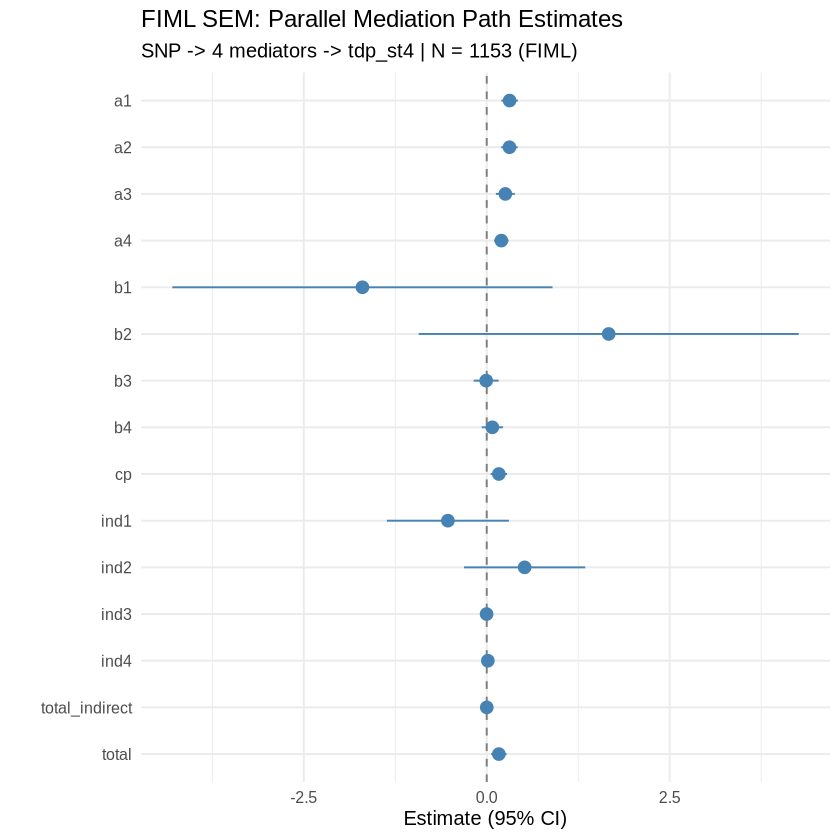

In [5]:
# ============================================================
# Section 5: FIML -- Save Results and Forest Plot
# ============================================================

contrast_labels <- c()
contrast_mediators <- c()
for (i in 1:(N_MED-1)) {
  for (j in (i+1):N_MED) {
    contrast_labels <- c(contrast_labels, sprintf("diff_%d_%d", i, j))
    contrast_mediators <- c(contrast_mediators, paste(MED_SHORT[i], "vs", MED_SHORT[j]))
  }
}

label_map <- data.frame(
  label = c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
            paste0("ind", 1:N_MED), "total_indirect", "total",
            paste0("prop", 1:N_MED), "prop_total",
            contrast_labels),
  path_type = c(rep("a_path", N_MED), rep("b_path", N_MED), "direct",
                rep("specific_indirect", N_MED), "total_indirect", "total",
                rep("prop_mediated", N_MED), "prop_total_mediated",
                rep("contrast", length(contrast_labels))),
  mediator = c(MED_SHORT, MED_SHORT, "all",
               MED_SHORT, "all", "all",
               MED_SHORT, "all",
               contrast_mediators),
  stringsAsFactors=FALSE
)

fiml_res <- merge(label_map, pe_fiml[pe_fiml$label != "", c("label","est","se","ci.lower","ci.upper","pvalue")],
                  by="label", all.x=TRUE)
fiml_res$method <- "FIML"
fiml_res$N <- N_TOTAL
fiml_res$exposure <- EXPOSURE
fiml_res$direction <- "D1"

write.csv(fiml_res, file.path(DIR_FIML, "fiml_all_paths.csv"), row.names=FALSE)
cat("Saved fiml_all_paths.csv\n")

plot_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                 paste0("ind", 1:N_MED), "total_indirect", "total")
plot_df <- fiml_res[fiml_res$label %in% plot_labels, ]
plot_df$label <- factor(plot_df$label, levels=rev(plot_labels))

p_fiml <- ggplot(plot_df, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(color="steelblue", size=0.6) +
  labs(title="FIML SEM: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> 4 mediators -> tdp_st4 | N = ", N_TOTAL, " (FIML)"),
       x="Estimate (95% CI)", y="") +
  theme_minimal(base_size=12)

ggsave(file.path(DIR_FIML, "fiml_forest_plot.png"), p_fiml, width=10, height=8, dpi=150)
ggsave(file.path(DIR_FIML, "fiml_forest_plot.pdf"), p_fiml, width=10, height=8)
cat("Saved FIML forest plots.\n")
print(p_fiml)

### FIML Interpretation

- **a-paths** (a1-a4): Effect of SNP on each mediator, controlling for mediator-specific covariates.
- **b-paths** (b1-b4): Effect of each mediator on tdp_st4, controlling for the SNP, other mediators, and outcome covariates.
- **c' (direct)**: Direct effect of SNP on tdp_st4, net of all four mediators.
- **Specific indirects** (ind1-ind4): Unique mediated effect through each mediator (ai x bi).
- **Total indirect**: Sum of all specific indirects.
- **Contrasts** (diff_i_j): Differences between specific indirect effects.
- **Proportions mediated**: Fraction of total effect transmitted through each mediator.

### Sensitivity Analysis: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp)

To assess whether the highly correlated mediators APOC4_APOC2_AC_exp and APOC2_AC_exp produce collinearity artifacts,
we re-fit the FIML SEM excluding APOC4_APOC2_AC_exp and retaining only APOC2_AC_exp, APOC1_DeJager_Mic_exp, and APOE_Mega_Mic_exp.
Results are saved to `main_SEM_FIML/sensitivity_analysis/`.

=== Sensitivity Analysis: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp) ===
N = 1153 
Mediators: APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp 

=== 3-Mediator Model ===
APOC2_AC_exp ~ a1 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a2 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a3 * chr19_44999110_TAAAA_TAA + msex_u + age_death_u + pmi_u
tdp_st4 ~ b1 * APOC2_AC_exp + b2 * APOC1_DeJager_Mic_exp + b3 * APOE_Mega_Mic_exp + cp * chr19_44999110_TAAAA_TAA + educ + apoe4_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
total_indirect := ind1 + ind2 + ind3
total := cp + total_indirect
prop1 := ind1 / total
prop2 := ind2 / total
prop3 := ind3 / total
prop_total := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_2_3 := ind2 - ind3
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp 



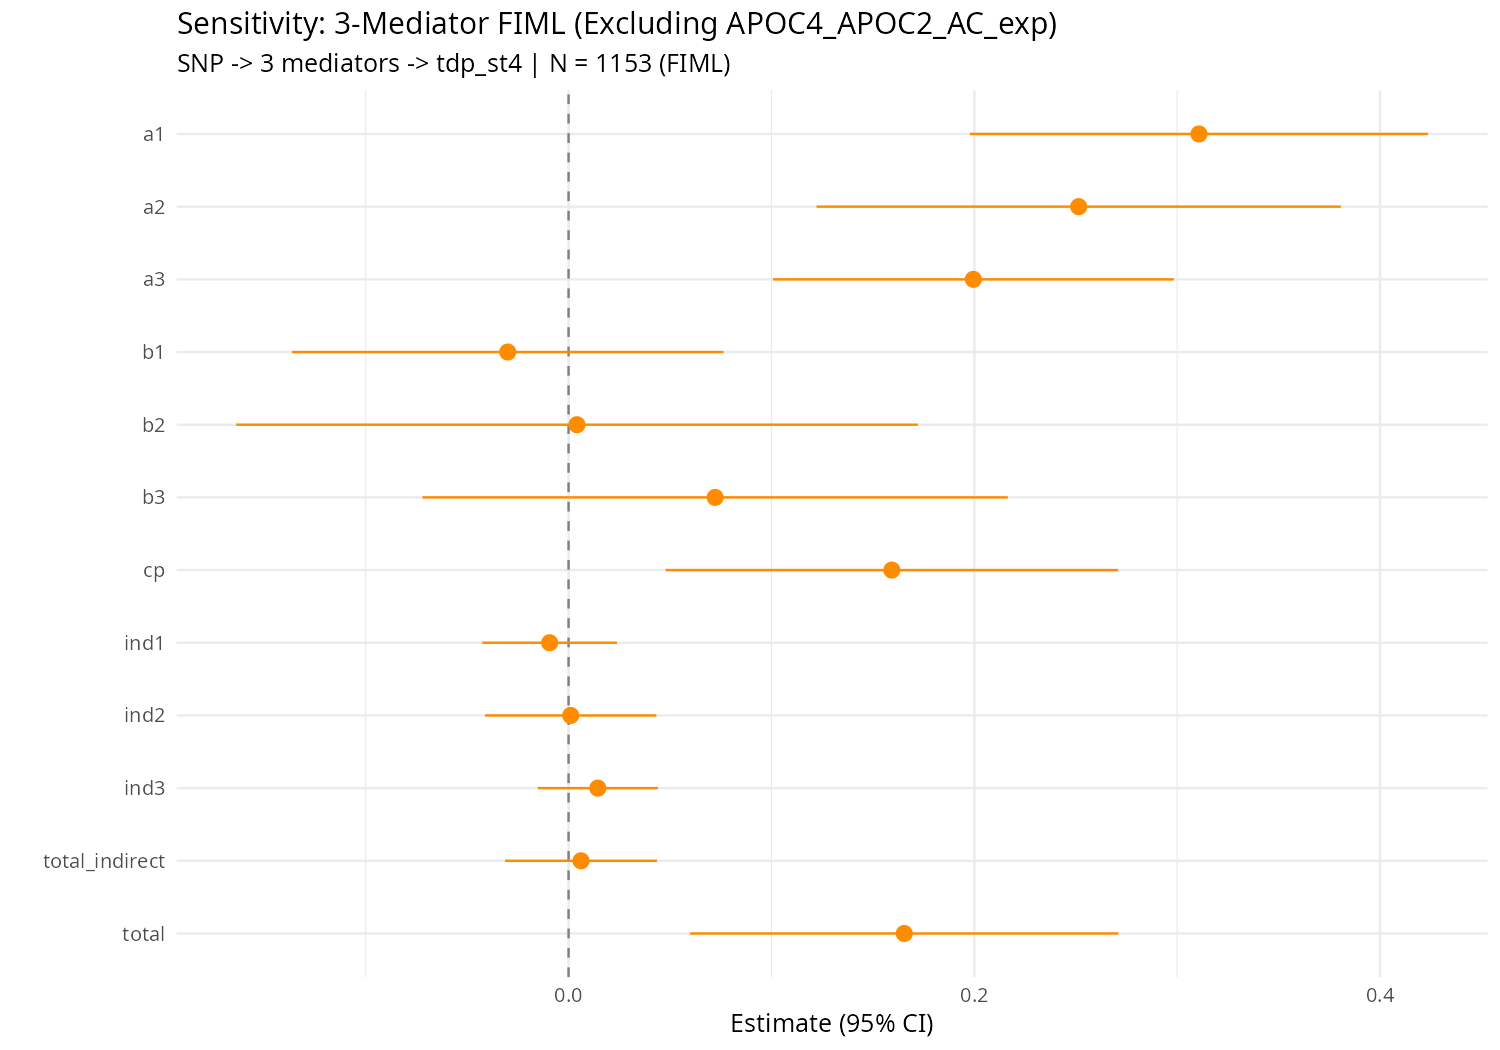

In [ ]:
# Sensitivity Analysis: 3-mediator parallel model (excluding APOC4_APOC2_AC_exp)
# Run inline - results saved to main_SEM_FIML/sensitivity_analysis/

suppressPackageStartupMessages({
  library(lavaan)
  library(ggplot2)
})

DATA_FILE <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE_ind_set_27_tdp_st4_mediation_all_input.txt"
RESULT_DIR <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/tdp_st4/APOE4_adj"
DIR_SENS <- file.path(RESULT_DIR, "main_SEM_FIML", "sensitivity_analysis")

EXPOSURE <- "chr19_44999110_TAAAA_TAA"
MEDIATORS_3 <- c("APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
OUTCOME <- "tdp_st4"
N_MED_3 <- length(MEDIATORS_3)
MED_SHORT_3 <- c("M2_APOC2", "M3_APOC1_DeJager", "M4_APOE_Mega")

COV_M2 <- c("msex_u", "age_death_u", "pmi_u", "ROS_study_u")
COV_M3 <- c("msex_u", "age_death_u", "pmi_u")
COV_M4 <- c("msex_u", "age_death_u", "pmi_u")
COV_Y  <- c("educ", "apoe4_dose", "msex_u", "age_death_u")
COV_LIST_3 <- list(COV_M2, COV_M3, COV_M4)

ALL_COVS_3 <- unique(c(COV_M2, COV_M3, COV_M4, COV_Y))

dat <- read.table(DATA_FILE, header=TRUE, sep="\t", stringsAsFactors=FALSE)
use_cols <- c(EXPOSURE, MEDIATORS_3, OUTCOME, ALL_COVS_3)
use_cols <- use_cols[use_cols %in% colnames(dat)]
dat <- dat[, use_cols]
N_TOTAL <- nrow(dat)

cat("=== Sensitivity Analysis: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp) ===\n")
cat("N =", N_TOTAL, "\n")
cat("Mediators:", paste(MEDIATORS_3, collapse=", "), "\n\n")

# Build model string
med_eqs <- character(N_MED_3)
for (i in seq_len(N_MED_3)) {
  cov_str <- paste(COV_LIST_3[[i]], collapse=" + ")
  med_eqs[i] <- sprintf("%s ~ a%d * %s + %s", MEDIATORS_3[i], i, EXPOSURE, cov_str)
}

y_med_terms <- paste0("b", seq_len(N_MED_3), " * ", MEDIATORS_3, collapse=" + ")
y_cov_str <- paste(COV_Y, collapse=" + ")
y_eq <- sprintf("%s ~ %s + cp * %s + %s", OUTCOME, y_med_terms, EXPOSURE, y_cov_str)

ind_defs <- paste0("ind", seq_len(N_MED_3), " := a", seq_len(N_MED_3), " * b", seq_len(N_MED_3))
total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(N_MED_3), collapse=" + "))
total_def <- "total := cp + total_indirect"

prop_defs <- paste0("prop", seq_len(N_MED_3), " := ind", seq_len(N_MED_3), " / total")
prop_total <- "prop_total := total_indirect / total"

contrasts <- c()
for (i in 1:(N_MED_3-1)) {
  for (j in (i+1):N_MED_3) {
    contrasts <- c(contrasts, sprintf("diff_%d_%d := ind%d - ind%d", i, j, i, j))
  }
}

cov_terms <- c()
for (i in 1:(N_MED_3-1)) {
  for (j in (i+1):N_MED_3) {
    cov_terms <- c(cov_terms, sprintf("%s ~~ %s", MEDIATORS_3[i], MEDIATORS_3[j]))
  }
}

model_str_3 <- paste(c(med_eqs, y_eq, ind_defs, total_ind, total_def, prop_defs, prop_total, contrasts, cov_terms),
                     collapse="\n")

cat("=== 3-Mediator Model ===\n")
cat(model_str_3, "\n\n")

# Fit FIML
fit_sens <- tryCatch(
  sem(model_str_3, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", conditionMessage(e), "\n"); NULL }
)

if (!is.null(fit_sens) && lavInspect(fit_sens, "converged")) {
  cat("FIML converged successfully.\n")
  cat("N used:", lavInspect(fit_sens, "nobs"), "\n\n")

  pe_sens <- parameterEstimates(fit_sens, ci=TRUE)

  labeled <- pe_sens[pe_sens$label != "", ]
  cat("=== All Labeled Parameter Estimates ===\n")
  print(labeled[, c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")])

  fm <- fitMeasures(fit_sens, c("chisq", "df", "pvalue", "cfi", "rmsea", "srmr", "aic", "bic"))
  cat("\n=== Fit Measures ===\n")
  print(round(fm, 4))

  # Build results table
  contrast_labels <- c()
  contrast_mediators <- c()
  for (i in 1:(N_MED_3-1)) {
    for (j in (i+1):N_MED_3) {
      contrast_labels <- c(contrast_labels, sprintf("diff_%d_%d", i, j))
      contrast_mediators <- c(contrast_mediators, paste(MED_SHORT_3[i], "vs", MED_SHORT_3[j]))
    }
  }

  label_map <- data.frame(
    label = c(paste0("a", 1:N_MED_3), paste0("b", 1:N_MED_3), "cp",
              paste0("ind", 1:N_MED_3), "total_indirect", "total",
              paste0("prop", 1:N_MED_3), "prop_total",
              contrast_labels),
    path_type = c(rep("a_path", N_MED_3), rep("b_path", N_MED_3), "direct",
                  rep("specific_indirect", N_MED_3), "total_indirect", "total",
                  rep("prop_mediated", N_MED_3), "prop_total_mediated",
                  rep("contrast", length(contrast_labels))),
    mediator = c(MED_SHORT_3, MED_SHORT_3, "all",
                 MED_SHORT_3, "all", "all",
                 MED_SHORT_3, "all",
                 contrast_mediators),
    stringsAsFactors=FALSE
  )

  sens_res <- merge(label_map, pe_sens[pe_sens$label != "", c("label","est","se","ci.lower","ci.upper","pvalue")],
                    by="label", all.x=TRUE)
  sens_res$method <- "FIML_sensitivity_3med"
  sens_res$N <- N_TOTAL
  sens_res$exposure <- EXPOSURE
  sens_res$direction <- "D1"

  write.csv(sens_res, file.path(DIR_SENS, "fiml_3med_all_paths.csv"), row.names=FALSE)
  cat("\nSaved fiml_3med_all_paths.csv\n")

  # Forest plot
  plot_labels <- c(paste0("a", 1:N_MED_3), paste0("b", 1:N_MED_3), "cp",
                   paste0("ind", 1:N_MED_3), "total_indirect", "total")
  plot_df <- sens_res[sens_res$label %in% plot_labels, ]
  plot_df$label <- factor(plot_df$label, levels=rev(plot_labels))

  p_sens <- ggplot(plot_df, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(color="darkorange", size=0.6) +
    labs(title="Sensitivity: 3-Mediator FIML (Excluding APOC4_APOC2_AC_exp)",
         subtitle=paste0("SNP -> 3 mediators -> tdp_st4 | N = ", N_TOTAL, " (FIML)"),
         x="Estimate (95% CI)", y="") +
    theme_minimal(base_size=12)

  ggsave(file.path(DIR_SENS, "fiml_3med_forest_plot.png"), p_sens, width=10, height=7, dpi=150)
  ggsave(file.path(DIR_SENS, "fiml_3med_forest_plot.pdf"), p_sens, width=10, height=7)
  cat("Saved sensitivity forest plots.\n")

  # Comparison table: 4-med vs 3-med for key effects
  fiml_4med <- read.csv(file.path(RESULT_DIR, "main_SEM_FIML", "fiml_all_paths.csv"), stringsAsFactors=FALSE)

  # Map shared labels: in 4-med model, the equivalent paths for M2/M3/M4 are a2/a3/a4, b2/b3/b4, ind2/ind3/ind4
  # In 3-med model, they are a1/a2/a3, b1/b2/b3, ind1/ind2/ind3
  compare_rows <- list()

  # a-paths comparison
  for (k in 1:3) {
    old_label <- paste0("a", k+1)
    new_label <- paste0("a", k)
    r4 <- fiml_4med[fiml_4med$label == old_label, ]
    r3 <- sens_res[sens_res$label == new_label, ]
    if (nrow(r4) > 0 && nrow(r3) > 0) {
      compare_rows[[length(compare_rows)+1]] <- data.frame(
        mediator = MED_SHORT_3[k],
        path = "a_path",
        est_4med = r4$est, se_4med = r4$se, p_4med = r4$pvalue,
        est_3med = r3$est, se_3med = r3$se, p_3med = r3$pvalue,
        stringsAsFactors=FALSE
      )
    }
  }

  # b-paths comparison
  for (k in 1:3) {
    old_label <- paste0("b", k+1)
    new_label <- paste0("b", k)
    r4 <- fiml_4med[fiml_4med$label == old_label, ]
    r3 <- sens_res[sens_res$label == new_label, ]
    if (nrow(r4) > 0 && nrow(r3) > 0) {
      compare_rows[[length(compare_rows)+1]] <- data.frame(
        mediator = MED_SHORT_3[k],
        path = "b_path",
        est_4med = r4$est, se_4med = r4$se, p_4med = r4$pvalue,
        est_3med = r3$est, se_3med = r3$se, p_3med = r3$pvalue,
        stringsAsFactors=FALSE
      )
    }
  }

  # indirect effects comparison
  for (k in 1:3) {
    old_label <- paste0("ind", k+1)
    new_label <- paste0("ind", k)
    r4 <- fiml_4med[fiml_4med$label == old_label, ]
    r3 <- sens_res[sens_res$label == new_label, ]
    if (nrow(r4) > 0 && nrow(r3) > 0) {
      compare_rows[[length(compare_rows)+1]] <- data.frame(
        mediator = MED_SHORT_3[k],
        path = "indirect",
        est_4med = r4$est, se_4med = r4$se, p_4med = r4$pvalue,
        est_3med = r3$est, se_3med = r3$se, p_3med = r3$pvalue,
        stringsAsFactors=FALSE
      )
    }
  }

  # cp and total_indirect
  for (lab in c("cp", "total_indirect", "total")) {
    r4 <- fiml_4med[fiml_4med$label == lab, ]
    r3 <- sens_res[sens_res$label == lab, ]
    if (nrow(r4) > 0 && nrow(r3) > 0) {
      compare_rows[[length(compare_rows)+1]] <- data.frame(
        mediator = "all",
        path = lab,
        est_4med = r4$est, se_4med = r4$se, p_4med = r4$pvalue,
        est_3med = r3$est, se_3med = r3$se, p_3med = r3$pvalue,
        stringsAsFactors=FALSE
      )
    }
  }

  compare_df <- do.call(rbind, compare_rows)
  write.csv(compare_df, file.path(DIR_SENS, "comparison_4med_vs_3med.csv"), row.names=FALSE)
  cat("\nSaved comparison_4med_vs_3med.csv\n")

  cat("\n=== 4-Mediator vs 3-Mediator Comparison ===\n")
  print(compare_df)

} else {
  cat("Sensitivity FIML failed to converge.\n")
}

cat("\nSensitivity analysis complete.\n")


---
## Method 2: Bootstrap (FIML Inside Each Replicate)

Non-parametric bootstrap with 1000 resamples. Each replicate fits the full parallel mediation model
using FIML, preserving the N = full sample structure. Percentile confidence intervals are computed.

In [6]:
# ============================================================
# Section 6: Bootstrap
# ============================================================
cat("Running", B_REPS, "bootstrap replicates with FIML inside...\n")

boot_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                 paste0("ind", 1:N_MED), "total_indirect", "total")
boot_mat <- matrix(NA, B_REPS, length(boot_labels), dimnames=list(NULL, boot_labels))

n_converged <- 0
t0 <- proc.time()

for (i in seq_len(B_REPS)) {
  idx <- sample(nrow(dat), replace=TRUE)
  boot_dat <- dat[idx, ]
  fit_b <- tryCatch(
    sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE, se="none", test="none"),
    error = function(e) NULL,
    warning = function(w) {
      tryCatch(sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE, se="none", test="none"),
               error = function(e) NULL)
    }
  )
  if (!is.null(fit_b) && lavInspect(fit_b, "converged")) {
    pe_b <- parameterEstimates(fit_b)
    for (lab in boot_labels) {
      row_b <- pe_b[pe_b$label == lab, ]
      if (nrow(row_b) == 1) boot_mat[i, lab] <- row_b$est
    }
    n_converged <- n_converged + 1
  }
  if (i %% 200 == 0) cat(sprintf("  %d/%d done (%d converged)\n", i, B_REPS, n_converged))
}

elapsed <- (proc.time() - t0)[3]
cat(sprintf("\nBootstrap complete: %d/%d converged (%.1f%%) in %.1f minutes\n",
            n_converged, B_REPS, n_converged/B_REPS*100, elapsed/60))

Running 1000 bootstrap replicates with FIML inside...


  200/1000 done (200 converged)
  400/1000 done (400 converged)
  600/1000 done (600 converged)
  800/1000 done (800 converged)
  1000/1000 done (1000 converged)



Bootstrap complete: 1000/1000 converged (100.0%) in 21.2 minutes


=== Bootstrap Results === 


            label           est         se    ci.lower   ci.upper pvalue
1              a1  0.3145518026 0.05676166  0.20404475 0.42847840  0.000
2              a2  0.3129849236 0.05703915  0.20238850 0.42561216  0.000
3              a3  0.2559612042 0.06496058  0.13600540 0.38668078  0.000
4              a4  0.2025980610 0.04926088  0.10640400 0.29487432  0.000
5              b1 -1.6976225320 1.33673379 -4.28266587 0.82274946  0.208
6              b2  1.6650275655 1.33591963 -0.83662448 4.27952162  0.224
7              b3 -0.0103682508 0.09097229 -0.19055030 0.17216146  0.890
8              b4  0.0788881631 0.07709506 -0.06888391 0.22540334  0.300
9              cp  0.1657191000 0.05885210  0.06111732 0.28031366  0.002
10           ind1 -0.5348934498 0.44605143 -1.47438489 0.26439793  0.208
11           ind2  0.5220297063 0.44351672 -0.25684618 1.45255153  0.224
12           ind3 -0.0030808936 0.02412959 -0.05124128 0.04333028  0.890
13           ind4  0.0161141071 0.01659000 -0.01377

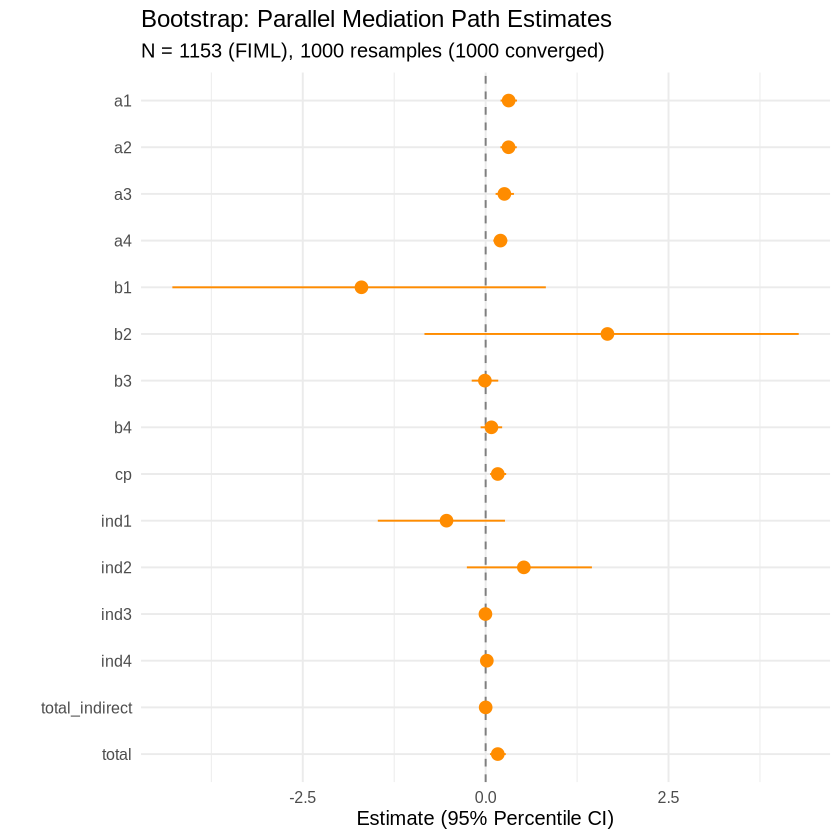

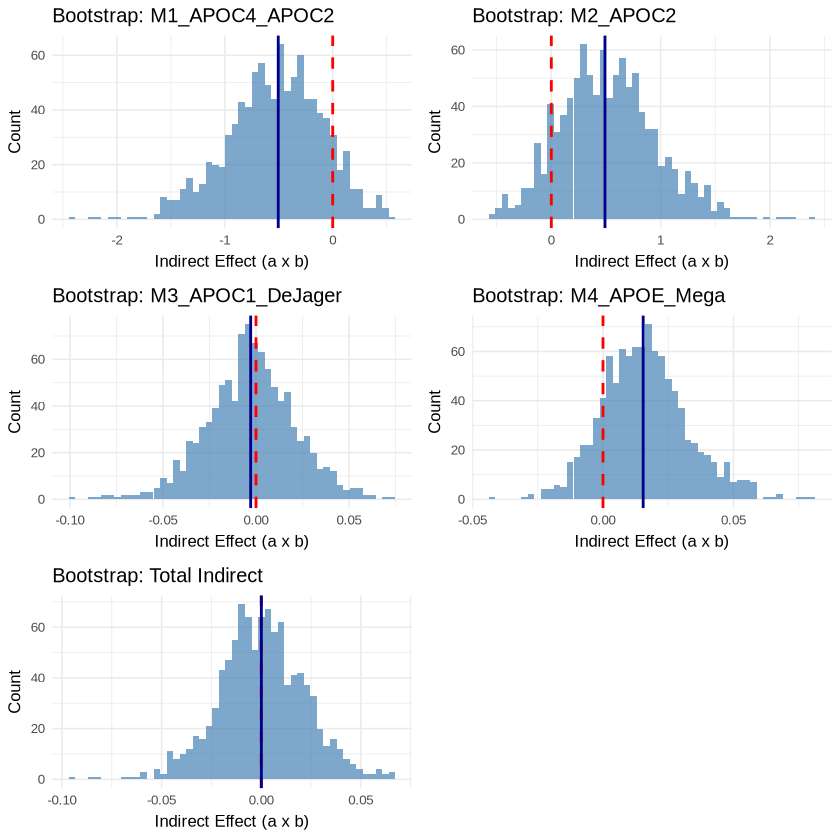

In [7]:
# ============================================================
# Section 7: Bootstrap -- Results, Forest Plot, Distributions
# ============================================================

boot_res <- data.frame(label=boot_labels, stringsAsFactors=FALSE)
boot_res$est <- apply(boot_mat, 2, mean, na.rm=TRUE)
boot_res$se <- apply(boot_mat, 2, sd, na.rm=TRUE)
boot_ci <- apply(boot_mat, 2, quantile, c(0.025, 0.975), na.rm=TRUE)
boot_res$ci.lower <- boot_ci[1, ]
boot_res$ci.upper <- boot_ci[2, ]

boot_res$pvalue <- sapply(boot_labels, function(lab) {
  vals <- boot_mat[, lab]; vals <- vals[!is.na(vals)]
  if (length(vals) < 10) return(NA)
  p_pos <- mean(vals > 0); 2 * min(p_pos, 1 - p_pos)
})

boot_res$method <- "Bootstrap"
boot_res$N <- N_TOTAL
boot_res$n_converged <- n_converged
boot_res$exposure <- EXPOSURE
boot_res$direction <- "D1"

write.csv(boot_res, file.path(DIR_BOOT, "bootstrap_results.csv"), row.names=FALSE)
cat("=== Bootstrap Results ===", "\n")
print(boot_res[, c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")])

# Forest plot
plot_df_b <- boot_res
plot_df_b$label <- factor(plot_df_b$label, levels=rev(boot_labels))

p_boot_forest <- ggplot(plot_df_b, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(color="darkorange", size=0.6) +
  labs(title="Bootstrap: Parallel Mediation Path Estimates",
       subtitle=paste0("N = ", N_TOTAL, " (FIML), ", B_REPS, " resamples (", n_converged, " converged)"),
       x="Estimate (95% Percentile CI)", y="") +
  theme_minimal(base_size=12)

ggsave(file.path(DIR_BOOT, "bootstrap_forest_plot.png"), p_boot_forest, width=10, height=8, dpi=150)
ggsave(file.path(DIR_BOOT, "bootstrap_forest_plot.pdf"), p_boot_forest, width=10, height=8)
print(p_boot_forest)

# Distribution histograms
ind_labels <- c(paste0("ind", 1:N_MED), "total_indirect")
ind_names <- c(MED_SHORT, "Total Indirect")

plot_list <- list()
for (k in seq_along(ind_labels)) {
  lab <- ind_labels[k]
  vals <- boot_mat[, lab]; vals <- vals[!is.na(vals)]
  df_hist <- data.frame(value=vals)
  med_val <- median(vals)
  plot_list[[k]] <- ggplot(df_hist, aes(x=value)) +
    geom_histogram(bins=50, fill="steelblue", alpha=0.7) +
    geom_vline(xintercept=0, linetype="dashed", color="red", linewidth=0.8) +
    geom_vline(xintercept=med_val, color="darkblue", linewidth=0.8) +
    labs(title=paste0("Bootstrap: ", ind_names[k]),
         x="Indirect Effect (a x b)", y="Count") +
    theme_minimal(base_size=10)
}

p_boot_dist <- do.call(gridExtra::grid.arrange, c(plot_list, ncol=2))
ggsave(file.path(DIR_BOOT, paste0("bootstrap_distributions_", EXPOSURE, ".png")),
       arrangeGrob(grobs=plot_list, ncol=2), width=12, height=10, dpi=150)
ggsave(file.path(DIR_BOOT, paste0("bootstrap_distributions_", EXPOSURE, ".pdf")),
       arrangeGrob(grobs=plot_list, ncol=2), width=12, height=10)

### Bootstrap Interpretation

Bootstrap provides non-parametric percentile confidence intervals that do not assume normality of the
indirect effect distribution. If a 95% percentile CI excludes zero, the indirect effect is significant
at alpha=0.05. The histograms show the sampling distributions of each specific and total indirect effect.

---
## Method 3: MNAR Sensitivity Analysis

Delta-shift imputation assesses robustness of the indirect effect to departures from Missing At Random.
For each grid point, missing mediators are shifted uniformly by delta_med * SD, and missing outcome by
delta_out * SD. The tipping point is the smallest shift that makes the total indirect non-significant.

In [8]:
# ============================================================
# Section 8: MNAR Sensitivity
# ============================================================
cat("Running MNAR sensitivity grid...\n")

delta_range <- seq(-3, 3, length.out=15)
grid <- expand.grid(delta_med=delta_range, delta_out=delta_range)
cat("Grid:", nrow(grid), "points\n")

med_means <- sapply(MEDIATORS, function(m) mean(dat[[m]], na.rm=TRUE))
med_sds   <- sapply(MEDIATORS, function(m) sd(dat[[m]], na.rm=TRUE))
out_mean  <- mean(dat[[OUTCOME]], na.rm=TRUE)
out_sd    <- sd(dat[[OUTCOME]], na.rm=TRUE)

mnar_labels <- c(paste0("ind", 1:N_MED), "total_indirect")
mnar_est <- matrix(NA, nrow(grid), length(mnar_labels), dimnames=list(NULL, mnar_labels))
mnar_pval <- matrix(NA, nrow(grid), length(mnar_labels), dimnames=list(NULL, mnar_labels))

t0 <- proc.time()
n_ok <- 0

for (k in 1:nrow(grid)) {
  dat_imp <- dat

  for (m_idx in seq_along(MEDIATORS)) {
    m <- MEDIATORS[m_idx]
    dat_imp[[m]][is.na(dat_imp[[m]])] <- med_means[m_idx] + grid$delta_med[k] * med_sds[m_idx]
  }
  dat_imp[[OUTCOME]][is.na(dat_imp[[OUTCOME]])] <- out_mean + grid$delta_out[k] * out_sd

  for (cov in ALL_COVS) {
    dat_imp[[cov]][is.na(dat_imp[[cov]])] <- mean(dat_imp[[cov]], na.rm=TRUE)
  }

  fit_m <- tryCatch(
    sem(model_str, data=dat_imp, estimator="ML", fixed.x=FALSE),
    error = function(e) NULL
  )

  if (!is.null(fit_m) && lavInspect(fit_m, "converged")) {
    pe_m <- parameterEstimates(fit_m)
    for (lab in mnar_labels) {
      row_m <- pe_m[pe_m$label == lab, ]
      if (nrow(row_m) == 1) {
        mnar_est[k, lab] <- row_m$est
        mnar_pval[k, lab] <- row_m$pvalue
      }
    }
    n_ok <- n_ok + 1
  }
}

elapsed <- (proc.time() - t0)[3]
cat(sprintf("MNAR grid complete: %d/%d converged in %.1f minutes\n", n_ok, nrow(grid), elapsed/60))

Running MNAR sensitivity grid...


Grid: 225 points


MNAR grid complete: 225/225 converged in 1.1 minutes


Tipping point (total indirect): delta_med=0.00, delta_out=0.00, distance=0.00
  At tipping: est=0.0022, p=0.8213



At reference (0,0): total_indirect=0.0022, p=0.8213


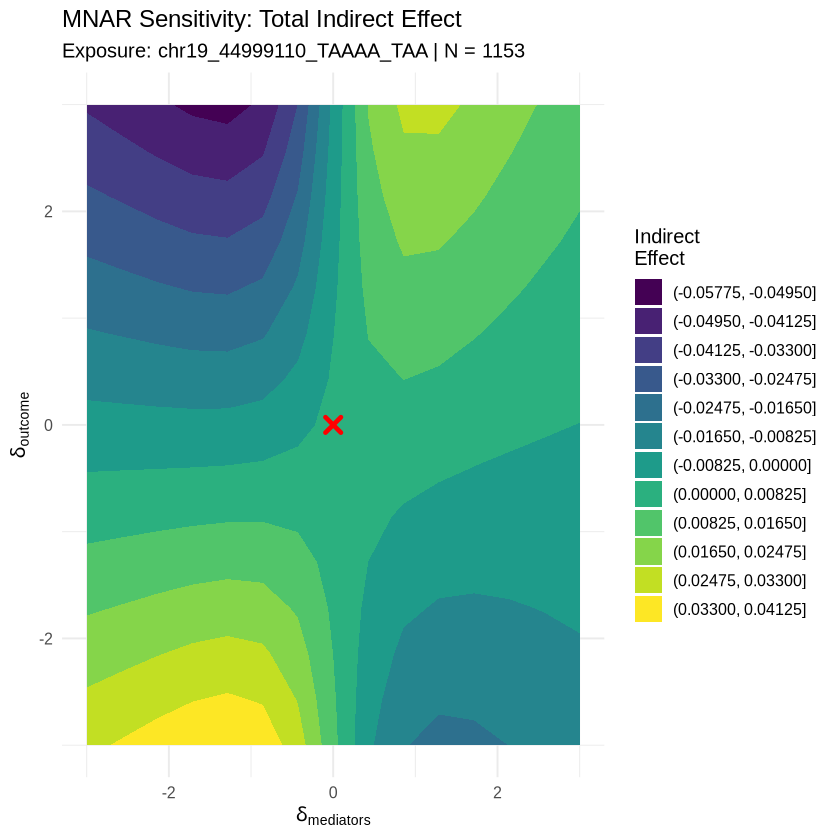

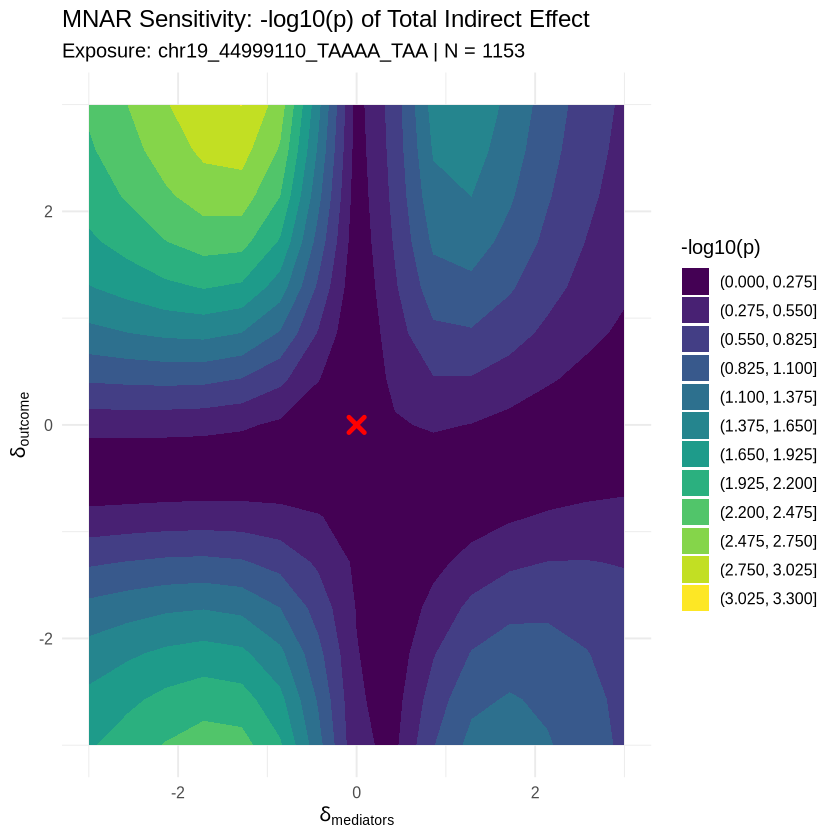

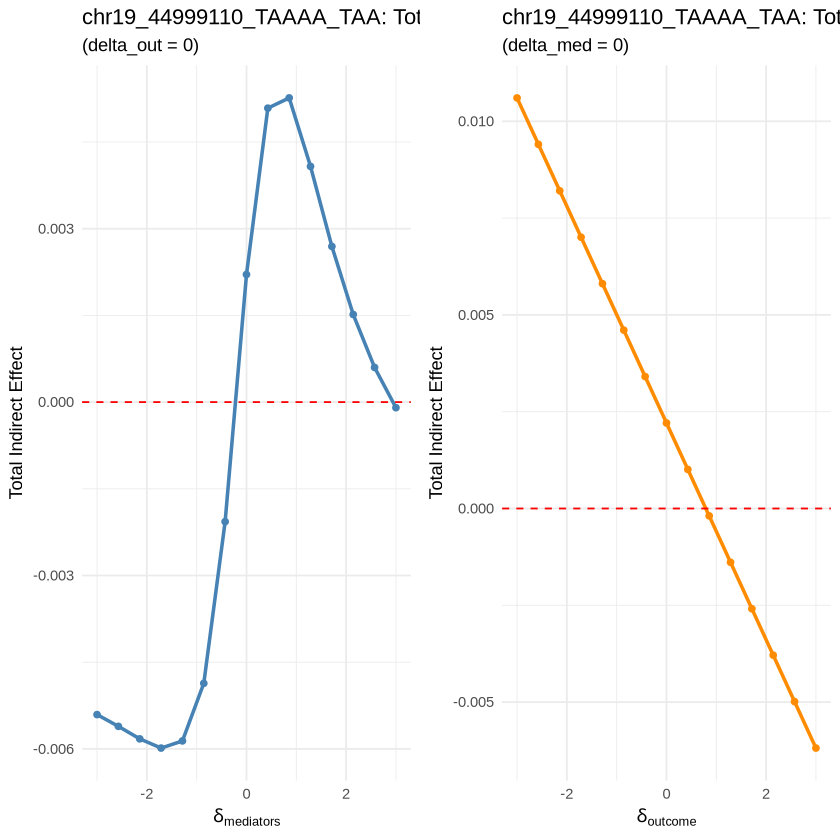

In [9]:
# ============================================================
# Section 9: MNAR -- Save Results, Contour Plots, 1D Slices
# ============================================================

mnar_grid_df <- cbind(grid,
                      as.data.frame(mnar_est),
                      setNames(as.data.frame(mnar_pval), paste0(colnames(mnar_pval), "_p")))
mnar_grid_df$N <- N_TOTAL
mnar_grid_df$exposure <- EXPOSURE
write.csv(mnar_grid_df, file.path(DIR_MNAR, "mnar_grid_results.csv"), row.names=FALSE)

mnar_grid_df$dist <- sqrt(mnar_grid_df$delta_med^2 + mnar_grid_df$delta_out^2)
ns_rows <- mnar_grid_df[!is.na(mnar_grid_df$total_indirect_p) & mnar_grid_df$total_indirect_p >= 0.05, ]

if (nrow(ns_rows) > 0) {
  tip_row <- ns_rows[which.min(ns_rows$dist), ]
  cat(sprintf("Tipping point (total indirect): delta_med=%.2f, delta_out=%.2f, distance=%.2f\n",
              tip_row$delta_med, tip_row$delta_out, tip_row$dist))
  cat(sprintf("  At tipping: est=%.4f, p=%.4f\n", tip_row$total_indirect, tip_row$total_indirect_p))
} else {
  cat("Total indirect remains significant across entire grid -- ROBUST.\n")
  tip_row <- data.frame(delta_med=NA, delta_out=NA, dist=Inf)
}

ref_row <- mnar_grid_df[which.min(abs(mnar_grid_df$delta_med) + abs(mnar_grid_df$delta_out)), ]
cat(sprintf("\nAt reference (0,0): total_indirect=%.4f, p=%.4f\n",
            ref_row$total_indirect, ref_row$total_indirect_p))

tip_summary <- data.frame(
  exposure = EXPOSURE, effect = "total_indirect",
  ref_est = ref_row$total_indirect, ref_p = ref_row$total_indirect_p,
  tip_delta_med = tip_row$delta_med, tip_delta_out = tip_row$delta_out,
  tip_distance = tip_row$dist, N = N_TOTAL
)
write.csv(tip_summary, file.path(DIR_MNAR, "mnar_tipping_summary.csv"), row.names=FALSE)

# Contour: indirect effect
p_contour_ind <- ggplot(mnar_grid_df[!is.na(mnar_grid_df$total_indirect), ],
                        aes(x=delta_med, y=delta_out, z=total_indirect)) +
  geom_contour_filled(bins=12) +
  scale_fill_viridis_d(option="viridis") +
  annotate("point", x=0, y=0, shape=4, size=3, color="red", stroke=2) +
  labs(title="MNAR Sensitivity: Total Indirect Effect",
       subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_TOTAL),
       x=expression(delta[mediators]), y=expression(delta[outcome]),
       fill="Indirect\nEffect") +
  theme_minimal(base_size=12)

ggsave(file.path(DIR_MNAR, paste0("mnar_contour_indirect_", EXPOSURE, ".png")),
       p_contour_ind, width=9, height=7, dpi=150)
ggsave(file.path(DIR_MNAR, paste0("mnar_contour_indirect_", EXPOSURE, ".pdf")),
       p_contour_ind, width=9, height=7)
print(p_contour_ind)

# Contour: p-value
mnar_grid_df$neg_log10_p <- -log10(pmax(mnar_grid_df$total_indirect_p, 1e-20))
p_contour_pval <- ggplot(mnar_grid_df[!is.na(mnar_grid_df$neg_log10_p), ],
                         aes(x=delta_med, y=delta_out, z=neg_log10_p)) +
  geom_contour_filled(bins=12) +
  scale_fill_viridis_d(option="viridis") +
  annotate("point", x=0, y=0, shape=4, size=3, color="red", stroke=2) +
  labs(title="MNAR Sensitivity: -log10(p) of Total Indirect Effect",
       subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_TOTAL),
       x=expression(delta[mediators]), y=expression(delta[outcome]),
       fill="-log10(p)") +
  theme_minimal(base_size=12)

ggsave(file.path(DIR_MNAR, paste0("mnar_contour_pvalue_", EXPOSURE, ".png")),
       p_contour_pval, width=9, height=7, dpi=150)
ggsave(file.path(DIR_MNAR, paste0("mnar_contour_pvalue_", EXPOSURE, ".pdf")),
       p_contour_pval, width=9, height=7)
print(p_contour_pval)

# 1D slices
slice_med <- mnar_grid_df[abs(mnar_grid_df$delta_out) < 0.01, ]
slice_out <- mnar_grid_df[abs(mnar_grid_df$delta_med) < 0.01, ]

p_slice1 <- ggplot(slice_med, aes(x=delta_med, y=total_indirect)) +
  geom_line(color="steelblue", linewidth=1) + geom_point(color="steelblue") +
  geom_hline(yintercept=0, linetype="dashed", color="red") +
  labs(title=paste0(EXPOSURE, ": Total Indirect vs delta_med"),
       subtitle="(delta_out = 0)",
       x=expression(delta[mediators]), y="Total Indirect Effect") +
  theme_minimal(base_size=11)

p_slice2 <- ggplot(slice_out, aes(x=delta_out, y=total_indirect)) +
  geom_line(color="darkorange", linewidth=1) + geom_point(color="darkorange") +
  geom_hline(yintercept=0, linetype="dashed", color="red") +
  labs(title=paste0(EXPOSURE, ": Total Indirect vs delta_out"),
       subtitle="(delta_med = 0)",
       x=expression(delta[outcome]), y="Total Indirect Effect") +
  theme_minimal(base_size=11)

p_slices <- gridExtra::grid.arrange(p_slice1, p_slice2, ncol=2)
ggsave(file.path(DIR_MNAR, paste0("mnar_1d_slices_", EXPOSURE, ".png")),
       arrangeGrob(p_slice1, p_slice2, ncol=2), width=14, height=5, dpi=150)
ggsave(file.path(DIR_MNAR, paste0("mnar_1d_slices_", EXPOSURE, ".pdf")),
       arrangeGrob(p_slice1, p_slice2, ncol=2), width=14, height=5)

### MNAR Interpretation

- The reference point (0,0) corresponds to MAR (missing values imputed at observed mean).
- The tipping point is the smallest shift from (0,0) that flips significance.
- Tipping distance > 1.0 SD: robust. Distance < 0.5 SD: fragile.

---
## Method 4: Bayesian SEM (blavaan)

Bayesian estimation via blavaan/Stan. Missing data handled by Stan data augmentation.
Posterior probability P(indirect > 0) provides Bayesian evidence measure.

In [10]:
# ============================================================
# Section 10: Bayesian SEM (blavaan)
# ============================================================
cat("Fitting Bayesian SEM with blavaan (2 chains, Stan backend)...\n")
cat("N =", N_TOTAL, "(full data with NAs, Stan handles missing)\n")

t0 <- proc.time()

fit_bayes <- tryCatch(
  bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
       n.chains=2, burnin=1000, sample=2000, seed=42),
  error = function(e) { cat("Bayesian Error:", conditionMessage(e), "\n"); NULL }
)

elapsed_bayes <- (proc.time() - t0)[3]
cat(sprintf("Bayesian fitting took %.1f minutes\n", elapsed_bayes / 60))

if (!is.null(fit_bayes)) {
  cat("Bayesian model fitted successfully.\n")
} else {
  cat("Bayesian model failed.\n")
}

Fitting Bayesian SEM with blavaan (2 chains, Stan backend)...


N = 1153 (full data with NAs, Stan handles missing)



SAMPLING FOR MODEL 'stanmarg' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.005576 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 55.76 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 3000 [  0%]  (Warmup)
Chain 1: Iteration:  300 / 3000 [ 10%]  (Warmup)
Chain 1: Iteration:  600 / 3000 [ 20%]  (Warmup)
Chain 1: Iteration:  900 / 3000 [ 30%]  (Warmup)
Chain 1: Iteration: 1001 / 3000 [ 33%]  (Sampling)
Chain 1: Iteration: 1300 / 3000 [ 43%]  (Sampling)
Chain 1: Iteration: 1600 / 3000 [ 53%]  (Sampling)
Chain 1: Iteration: 1900 / 3000 [ 63%]  (Sampling)
Chain 1: Iteration: 2200 / 3000 [ 73%]  (Sampling)
Chain 1: Iteration: 2500 / 3000 [ 83%]  (Sampling)
Chain 1: Iteration: 2800 / 3000 [ 93%]  (Sampling)
Chain 1: Iteration: 3000 / 3000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1727.91 seconds (Warm-up)
Chain 1:                4012.19 seconds (Sampling)
Chain 1:            

Warning message:
“There were 4000 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded”


Warning message:
“Examine the pairs() plot to diagnose sampling problems
”


...

Warning message:
“Tail Effective Samples Size (ESS) is too low, indicating posterior variances and tail quantiles may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#tail-ess”


Computing post-estimation metrics (including lvs if requested)...


Warning message:
“lavaan->lav_model_vcov_se():  
   The following boostrapped defined parameters have a high (>5) ratio of 
   standard deviation to median absolute deviation: prop1 prop2 prop3 prop4 
   prop_total. P-values and confidence intervals may not match.”


Bayesian fitting took 192.7 minutes


Bayesian model fitted successfully.


In [11]:
# ============================================================
# Section 11: Bayesian -- Extract Results
# ============================================================

if (!is.null(fit_bayes)) {
  pt <- parTable(fit_bayes)
  labeled_pt <- pt[pt$label != "", c("label", "est", "se")]
  cat("=== Bayesian Parameter Estimates (parTable) ===", "\n")
  print(labeled_pt)

  draws_raw <- blavInspect(fit_bayes, "draws")
  draws <- do.call(rbind, draws_raw)
  cat("\nPosterior draws dimensions:", nrow(draws), "x", ncol(draws), "\n")
  draw_colnames <- colnames(draws)
  cat("Draw column names (first 20):", paste(head(draw_colnames, 20), collapse=", "), "\n")

  bayes_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                    paste0("ind", 1:N_MED), "total_indirect", "total")

  bayes_res <- data.frame(label=character(), est=numeric(), se=numeric(),
                          ci.lower=numeric(), ci.upper=numeric(),
                          pp_positive=numeric(), stringsAsFactors=FALSE)

  for (lab in bayes_labels) {
    d <- NULL
    if (lab %in% draw_colnames) {
      d <- draws[, lab]
    } else {
      pt_row <- pt[pt$label == lab, ]
      if (nrow(pt_row) > 0) {
        plabel <- pt_row$plabel[1]
        if (!is.null(plabel) && plabel %in% draw_colnames) {
          d <- draws[, plabel]
        }
      }
    }

    if (!is.null(d)) {
      ci <- quantile(d, c(0.025, 0.975))
      bayes_res <- rbind(bayes_res, data.frame(
        label=lab, est=mean(d), se=sd(d),
        ci.lower=ci[1], ci.upper=ci[2],
        pp_positive=mean(d > 0), stringsAsFactors=FALSE
      ))
    } else {
      pt_row <- pt[pt$label == lab, ]
      if (nrow(pt_row) > 0) {
        bayes_res <- rbind(bayes_res, data.frame(
          label=lab, est=pt_row$est[1], se=pt_row$se[1],
          ci.lower=pt_row$est[1] - 1.96*pt_row$se[1],
          ci.upper=pt_row$est[1] + 1.96*pt_row$se[1],
          pp_positive=NA, stringsAsFactors=FALSE
        ))
      }
    }
  }

  rownames(bayes_res) <- NULL
  bayes_res$method <- "Bayesian"
  bayes_res$N <- N_TOTAL
  bayes_res$exposure <- EXPOSURE
  bayes_res$direction <- "D1"

  write.csv(bayes_res, file.path(DIR_BAYES, "bayesian_results.csv"), row.names=FALSE)
  cat("\n=== Bayesian Results ===", "\n")
  print(bayes_res[, c("label", "est", "se", "ci.lower", "ci.upper", "pp_positive")])
} else {
  cat("Skipping Bayesian results extraction (model failed).\n")
  bayes_res <- NULL
}

=== Bayesian Parameter Estimates (parTable) === 
            label    est     se
1              a1  0.309  0.060
6              a2  0.308  0.060
11             a3  0.259  0.063
15             a4  0.205  0.048
19             b1 -1.670  1.268
20             b2  1.643  1.268
21             b3 -0.016  0.082
22             b4  0.083  0.071
23             cp  0.162  0.056
79           ind1 -0.517  0.418
80           ind2  0.506  0.415
81           ind3 -0.004  0.022
82           ind4  0.017  0.015
83 total_indirect  0.002  0.021
84          total  0.163  0.053
85          prop1 -3.163 27.490
86          prop2  3.094 26.926
87          prop3 -0.025  0.947
88          prop4  0.104  0.695
89     prop_total  0.010  1.100
90       diff_1_2 -1.022  0.833
91       diff_1_3 -0.513  0.416
92       diff_1_4 -0.534  0.418
93       diff_2_3  0.510  0.418
94       diff_2_4  0.489  0.415
95       diff_3_4 -0.021  0.034

Posterior draws dimensions: 4000 x 95 
Draw column names (first 20): a1, APOC4_APOC2_A

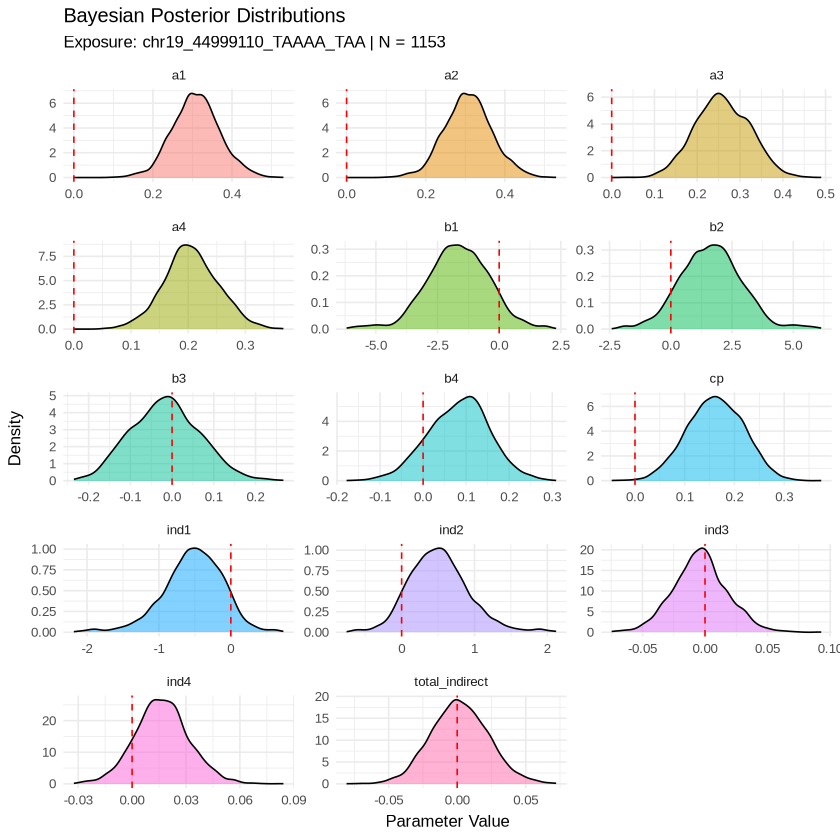

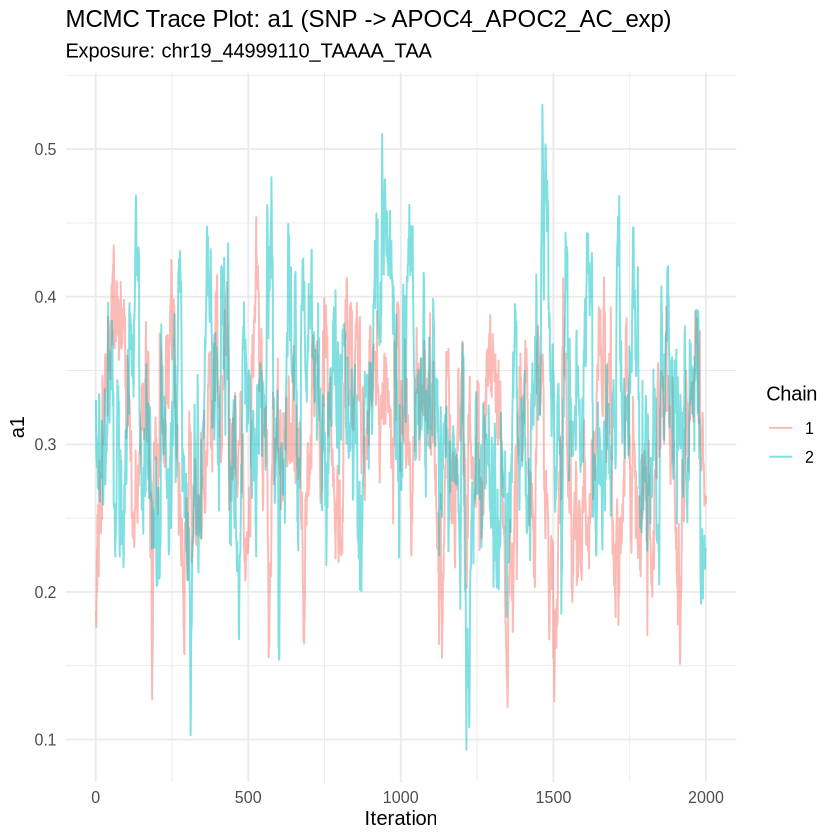

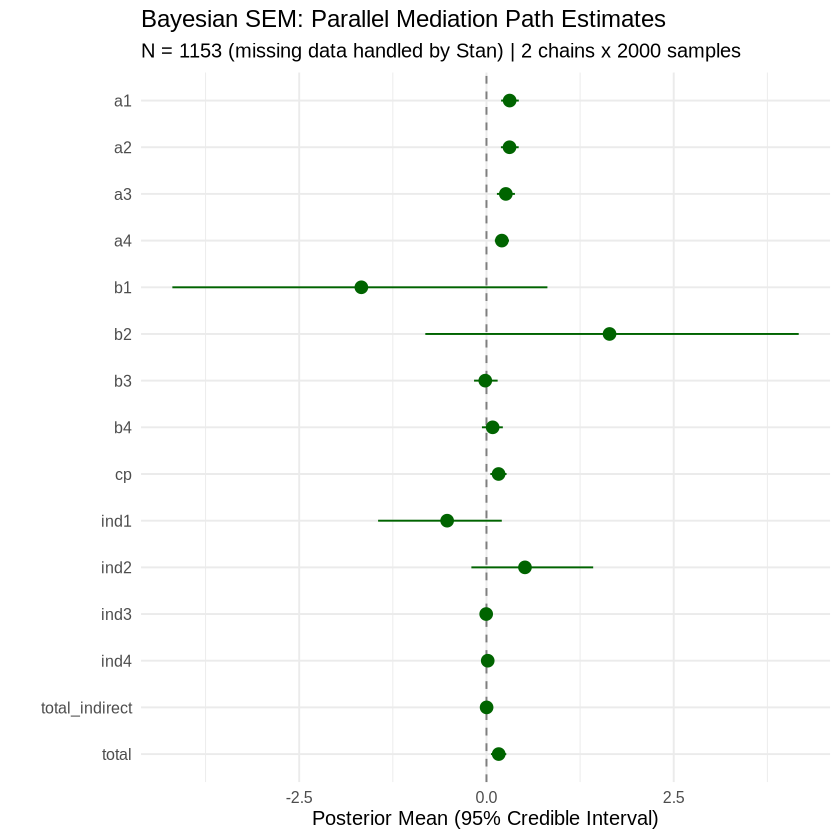

In [12]:
# ============================================================
# Section 12: Bayesian -- Plots
# ============================================================

if (!is.null(fit_bayes) && exists("bayes_res") && !is.null(bayes_res)) {

  density_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                      paste0("ind", 1:N_MED), "total_indirect")
  density_data <- data.frame()

  for (lab in density_labels) {
    d <- NULL
    if (lab %in% colnames(draws)) {
      d <- draws[, lab]
    } else {
      pt_row <- pt[pt$label == lab, ]
      if (nrow(pt_row) > 0 && !is.null(pt_row$plabel[1]) && pt_row$plabel[1] %in% colnames(draws)) {
        d <- draws[, pt_row$plabel[1]]
      }
    }
    if (!is.null(d)) {
      density_data <- rbind(density_data, data.frame(parameter=lab, value=d))
    }
  }

  if (nrow(density_data) > 0) {
    p_post <- ggplot(density_data, aes(x=value, fill=parameter)) +
      geom_density(alpha=0.5) +
      geom_vline(xintercept=0, linetype="dashed", color="red") +
      facet_wrap(~parameter, scales="free", ncol=3) +
      labs(title="Bayesian Posterior Distributions",
           subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_TOTAL),
           x="Parameter Value", y="Density") +
      theme_minimal(base_size=10) +
      theme(legend.position="none")

    n_panels <- length(unique(density_data$parameter))
    plot_h <- max(6, ceiling(n_panels / 3) * 3)
    ggsave(file.path(DIR_BAYES, paste0("bayesian_posteriors_", EXPOSURE, ".png")),
           p_post, width=12, height=plot_h, dpi=150)
    ggsave(file.path(DIR_BAYES, paste0("bayesian_posteriors_", EXPOSURE, ".pdf")),
           p_post, width=12, height=plot_h)
    print(p_post)
  }

  # Trace plot for a1
  a1_col <- NULL
  if ("a1" %in% colnames(draws)) {
    a1_col <- "a1"
  } else {
    pt_a1 <- pt[pt$label == "a1", ]
    if (nrow(pt_a1) > 0 && !is.null(pt_a1$plabel[1]) && pt_a1$plabel[1] %in% colnames(draws)) {
      a1_col <- pt_a1$plabel[1]
    }
  }

  if (!is.null(a1_col)) {
    n_chains <- length(draws_raw)
    trace_data <- data.frame()
    for (ch in seq_len(n_chains)) {
      ch_draws <- as.matrix(draws_raw[[ch]])
      if (a1_col %in% colnames(ch_draws)) {
        trace_data <- rbind(trace_data, data.frame(
          iteration=seq_len(nrow(ch_draws)),
          value=ch_draws[, a1_col],
          chain=factor(ch)
        ))
      }
    }

    if (nrow(trace_data) > 0) {
      p_trace <- ggplot(trace_data, aes(x=iteration, y=value, color=chain)) +
        geom_line(alpha=0.5) +
        labs(title="MCMC Trace Plot: a1 (SNP -> APOC4_APOC2_AC_exp)",
             subtitle=paste0("Exposure: ", EXPOSURE),
             x="Iteration", y="a1", color="Chain") +
        theme_minimal(base_size=12)

      ggsave(file.path(DIR_BAYES, paste0("bayesian_trace_a_", EXPOSURE, ".png")),
             p_trace, width=10, height=5, dpi=150)
      ggsave(file.path(DIR_BAYES, paste0("bayesian_trace_a_", EXPOSURE, ".pdf")),
             p_trace, width=10, height=5)
      print(p_trace)
    }
  }

  # Bayesian forest plot
  bayes_plot_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                         paste0("ind", 1:N_MED), "total_indirect", "total")
  bayes_plot_df <- bayes_res[bayes_res$label %in% bayes_plot_labels, ]
  bayes_plot_df$label <- factor(bayes_plot_df$label, levels=rev(bayes_plot_labels))

  p_bayes_forest <- ggplot(bayes_plot_df, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(color="darkgreen", size=0.6) +
    labs(title="Bayesian SEM: Parallel Mediation Path Estimates",
         subtitle=paste0("N = ", N_TOTAL, " (missing data handled by Stan) | 2 chains x 2000 samples"),
         x="Posterior Mean (95% Credible Interval)", y="") +
    theme_minimal(base_size=12)

  ggsave(file.path(DIR_BAYES, "bayesian_forest_plot.png"), p_bayes_forest, width=10, height=8, dpi=150)
  ggsave(file.path(DIR_BAYES, "bayesian_forest_plot.pdf"), p_bayes_forest, width=10, height=8)
  print(p_bayes_forest)

} else {
  cat("Skipping Bayesian plots (model not available).\n")
}

### Bayesian Interpretation

- **Posterior mean**: Point estimate analogous to FIML ML estimate.
- **95% Credible Interval**: 95% of posterior probability falls within this range.
- **P(indirect > 0)**: Bayesian posterior probability; P > 0.975 or P < 0.025 suggests strong evidence.
- **Trace plots**: Chains should mix well and overlap for reliable posterior estimates.

---
## Cross-Method Summary

Combining results from all four methods into a unified comparison.

In [13]:
# ============================================================
# Section 13: Cross-Method Summary
# ============================================================

summary_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                     paste0("ind", 1:N_MED), "total_indirect", "total")

fiml_sub <- fiml_res[fiml_res$label %in% summary_labels,
                     c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")]
fiml_sub$method <- "FIML"
fiml_sub$ci_type <- "Wald"
fiml_sub$n_eff <- paste0("N=", N_TOTAL, " (FIML)")

boot_sub <- boot_res[boot_res$label %in% summary_labels,
                     c("label", "est", "se", "ci.lower", "ci.upper", "pvalue")]
boot_sub$method <- "Bootstrap"
boot_sub$ci_type <- "Percentile"
boot_sub$n_eff <- paste0("N=", N_TOTAL, " (Bootstrap FIML, ", n_converged, " reps)")

if (!is.null(bayes_res)) {
  bayes_sub <- bayes_res[bayes_res$label %in% summary_labels,
                         c("label", "est", "se", "ci.lower", "ci.upper")]
  pp_vals <- bayes_res$pp_positive[bayes_res$label %in% summary_labels]
  bayes_sub$pvalue <- ifelse(!is.na(pp_vals), 2 * pmin(pp_vals, 1 - pp_vals), NA)
  bayes_sub$method <- "Bayesian"
  bayes_sub$ci_type <- "Credible"
  bayes_sub$n_eff <- paste0("N=", N_TOTAL, " (Bayesian, fixed.x=FALSE)")
} else {
  bayes_sub <- NULL
}

all_summary <- rbind(fiml_sub, boot_sub, bayes_sub)
all_summary$exposure <- EXPOSURE
all_summary$direction <- "D1"

write.csv(all_summary, file.path(DIR_SUMM, "all_methods_summary.csv"), row.names=FALSE)
cat("=== Cross-Method Summary ===", "\n")
print(all_summary[order(all_summary$label, all_summary$method),
                  c("label", "method", "est", "se", "ci.lower", "ci.upper", "pvalue", "n_eff")])

# Wide display table
display_df <- data.frame(label=summary_labels)
for (meth in c("FIML", "Bootstrap", "Bayesian")) {
  sub <- all_summary[all_summary$method == meth, ]
  est_str <- sapply(summary_labels, function(lab) {
    row <- sub[sub$label == lab, ]
    if (nrow(row) == 1) sprintf("%.4f [%.4f, %.4f]", row$est, row$ci.lower, row$ci.upper)
    else "--"
  })
  p_str <- sapply(summary_labels, function(lab) {
    row <- sub[sub$label == lab, ]
    if (nrow(row) == 1 && !is.na(row$pvalue)) sprintf("%.4f", row$pvalue)
    else "--"
  })
  display_df[[paste0(meth, "_est_CI")]] <- est_str
  display_df[[paste0(meth, "_p")]] <- p_str
}

write.csv(display_df, file.path(DIR_SUMM, paste0("summary_display_table_", EXPOSURE, ".csv")),
          row.names=FALSE)
cat("\n=== Display Table ===", "\n")
print(display_df)

=== Cross-Method Summary === 


             label    method           est         se    ci.lower   ci.upper
111             a1  Bayesian  0.3094318795 0.05969376  0.19542321 0.43138504
110             a1 Bootstrap  0.3145518026 0.05676166  0.20404475 0.42847840
1               a1      FIML  0.3123860938 0.05750769  0.19967310 0.42509909
22              a2  Bayesian  0.3077104391 0.05978140  0.19298580 0.42995953
21              a2 Bootstrap  0.3129849236 0.05703915  0.20238850 0.42561216
2               a2      FIML  0.3106715148 0.05758342  0.19781008 0.42353295
32              a3  Bayesian  0.2586724181 0.06319289  0.13935518 0.37979296
31              a3 Bootstrap  0.2559612042 0.06496058  0.13600540 0.38668078
3               a3      FIML  0.2543528038 0.06592321  0.12514569 0.38355992
42              a4  Bayesian  0.2051317419 0.04780898  0.11150216 0.30039821
41              a4 Bootstrap  0.2025980610 0.04926088  0.10640400 0.29487432
4               a4      FIML  0.1997224437 0.05042795  0.10088548 0.29855941


=== Display Table === 


            label               FIML_est_CI FIML_p          Bootstrap_est_CI
1              a1   0.3124 [0.1997, 0.4251] 0.0000   0.3146 [0.2040, 0.4285]
2              a2   0.3107 [0.1978, 0.4235] 0.0000   0.3130 [0.2024, 0.4256]
3              a3   0.2544 [0.1251, 0.3836] 0.0001   0.2560 [0.1360, 0.3867]
4              a4   0.1997 [0.1009, 0.2986] 0.0001   0.2026 [0.1064, 0.2949]
5              b1 -1.6984 [-4.2957, 0.8989] 0.2000 -1.6976 [-4.2827, 0.8227]
6              b2  1.6665 [-0.9299, 4.2629] 0.2084  1.6650 [-0.8366, 4.2795]
7              b3 -0.0078 [-0.1782, 0.1626] 0.9288 -0.0104 [-0.1906, 0.1722]
8              b4  0.0765 [-0.0686, 0.2217] 0.3015  0.0789 [-0.0689, 0.2254]
9              cp   0.1654 [0.0535, 0.2772] 0.0038   0.1657 [0.0611, 0.2803]
10           ind1 -0.5306 [-1.3642, 0.3030] 0.2122 -0.5349 [-1.4744, 0.2644]
11           ind2  0.5177 [-0.3106, 1.3461] 0.2206  0.5220 [-0.2568, 1.4526]
12           ind3 -0.0020 [-0.0453, 0.0414] 0.9288 -0.0031 [-0.0512, 0.0433]

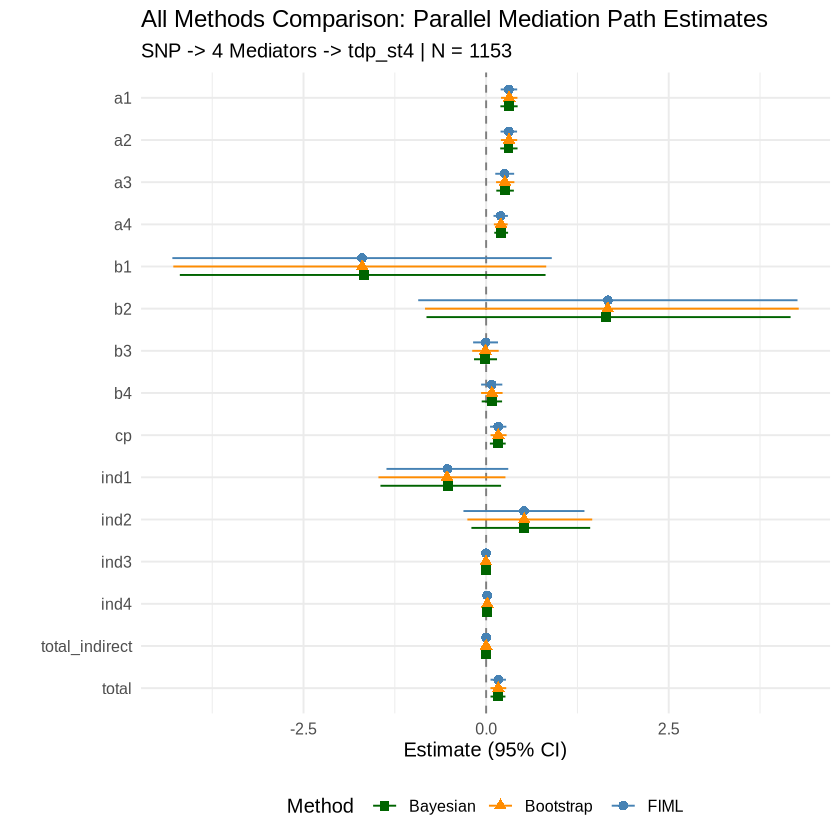

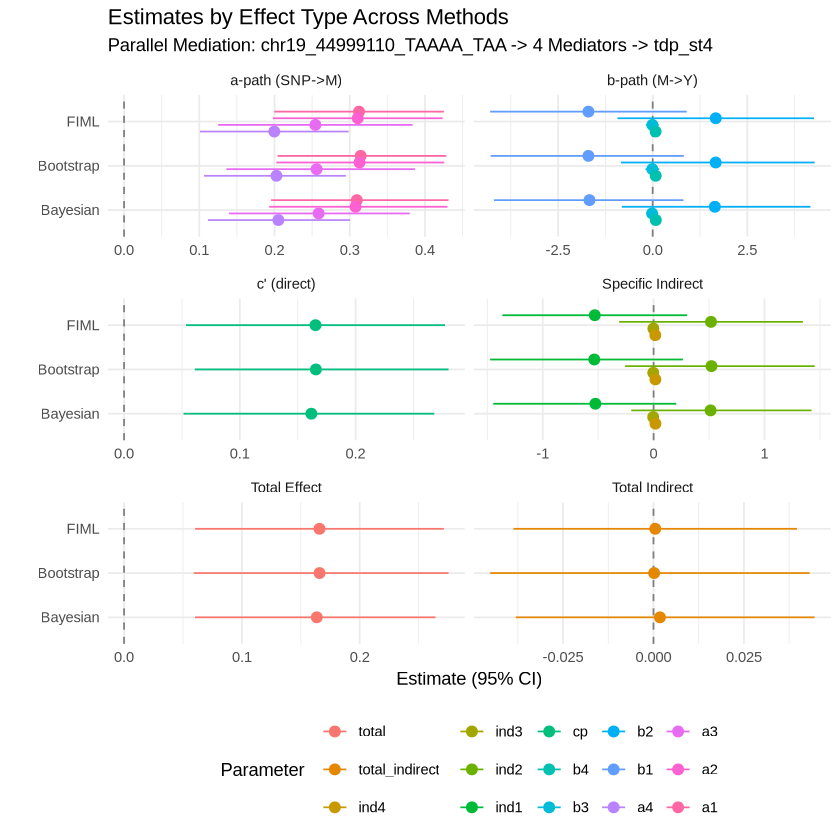

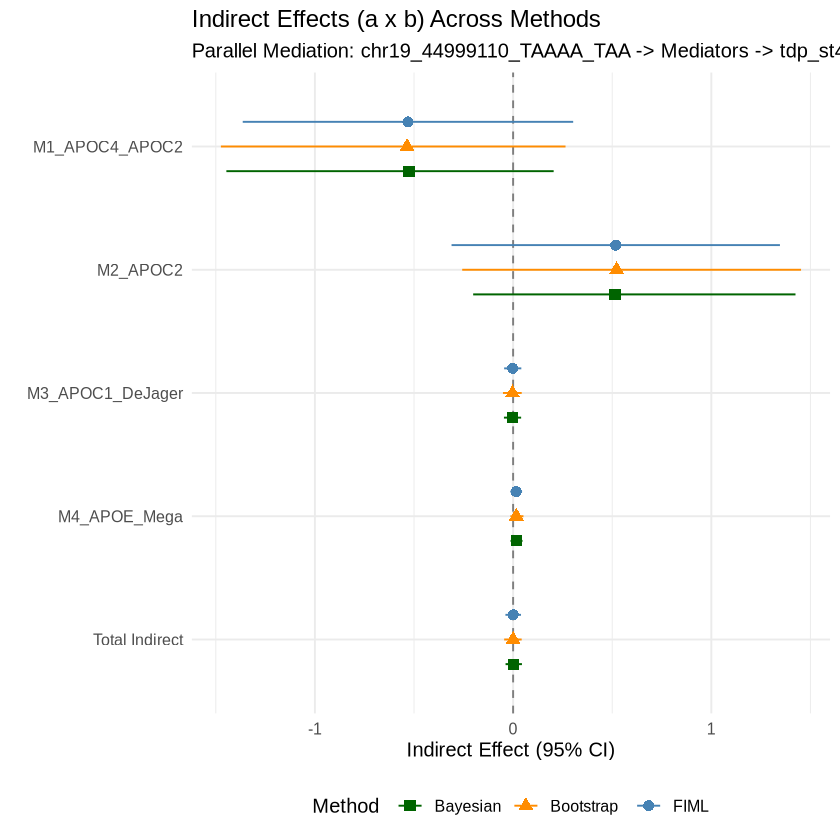

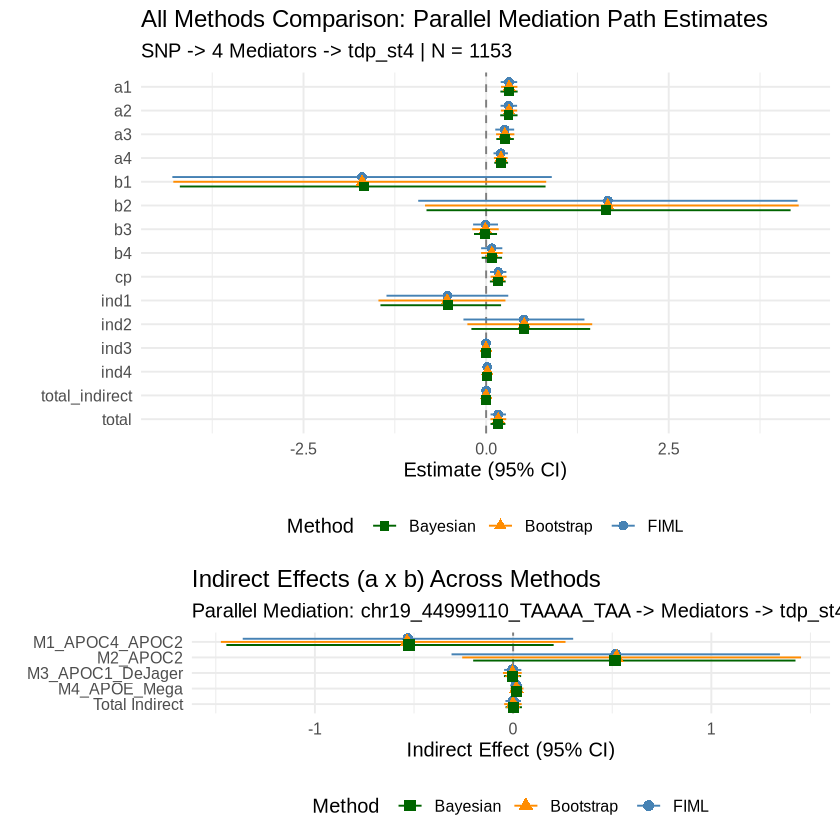

In [14]:
# ============================================================
# Section 14: Summary Visualizations
# ============================================================

method_colors <- c("FIML"="steelblue", "Bootstrap"="darkorange", "Bayesian"="darkgreen")
method_shapes <- c("FIML"=16, "Bootstrap"=17, "Bayesian"=15)

# A. All Methods Forest Plot
plot_all <- all_summary[all_summary$label %in% summary_labels, ]
plot_all$label <- factor(plot_all$label, levels=rev(summary_labels))

p_all_forest <- ggplot(plot_all, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper,
                                     color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.5) +
  scale_color_manual(values=method_colors) +
  scale_shape_manual(values=method_shapes) +
  labs(title="All Methods Comparison: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> 4 Mediators -> tdp_st4 | N = ", N_TOTAL),
       x="Estimate (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(DIR_SUMM, "summary_forest_all_methods.png"), p_all_forest, width=11, height=9, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_forest_all_methods.pdf"), p_all_forest, width=11, height=9)
print(p_all_forest)

# B. Faceted by Effect Type
plot_all2 <- plot_all
plot_all2$effect_type <- NA
plot_all2$effect_type[grepl("^a[0-9]", plot_all2$label)] <- "a-path (SNP->M)"
plot_all2$effect_type[grepl("^b[0-9]", plot_all2$label)] <- "b-path (M->Y)"
plot_all2$effect_type[plot_all2$label == "cp"] <- "c' (direct)"
plot_all2$effect_type[grepl("^ind[0-9]", plot_all2$label)] <- "Specific Indirect"
plot_all2$effect_type[plot_all2$label == "total_indirect"] <- "Total Indirect"
plot_all2$effect_type[plot_all2$label == "total"] <- "Total Effect"

p_faceted <- ggplot(plot_all2[!is.na(plot_all2$effect_type), ],
                    aes(x=est, y=method, xmin=ci.lower, xmax=ci.upper, color=label)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.5) +
  facet_wrap(~effect_type, scales="free_x", ncol=2) +
  labs(title="Estimates by Effect Type Across Methods",
       subtitle=paste0("Parallel Mediation: ", EXPOSURE, " -> 4 Mediators -> tdp_st4"),
       x="Estimate (95% CI)", y="", color="Parameter") +
  theme_minimal(base_size=11) +
  theme(legend.position="bottom")

ggsave(file.path(DIR_SUMM, "summary_faceted_by_path.png"), p_faceted, width=13, height=10, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_faceted_by_path.pdf"), p_faceted, width=13, height=10)
print(p_faceted)

# C. Indirect Effect Focus
ind_eff_labels <- c(paste0("ind", 1:N_MED), "total_indirect")
ind_eff_names <- c(MED_SHORT, "Total Indirect")
plot_ind <- all_summary[all_summary$label %in% ind_eff_labels, ]
plot_ind$label_nice <- ind_eff_names[match(plot_ind$label, ind_eff_labels)]
plot_ind$label_nice <- factor(plot_ind$label_nice, levels=rev(ind_eff_names))

p_indirect <- ggplot(plot_ind, aes(x=est, y=label_nice, xmin=ci.lower, xmax=ci.upper,
                                   color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.6) +
  scale_color_manual(values=method_colors) +
  scale_shape_manual(values=method_shapes) +
  labs(title="Indirect Effects (a x b) Across Methods",
       subtitle=paste0("Parallel Mediation: ", EXPOSURE, " -> Mediators -> tdp_st4 | N = ", N_TOTAL),
       x="Indirect Effect (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(DIR_SUMM, "summary_indirect_effect.png"), p_indirect, width=10, height=5, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_indirect_effect.pdf"), p_indirect, width=10, height=5)
print(p_indirect)

# D. Combined Panel
p_combined <- gridExtra::grid.arrange(p_all_forest, p_indirect, nrow=2, heights=c(2, 1))
ggsave(file.path(DIR_SUMM, "summary_combined_panel.png"),
       arrangeGrob(p_all_forest, p_indirect, nrow=2, heights=c(2, 1)),
       width=11, height=14, dpi=150)
ggsave(file.path(DIR_SUMM, "summary_combined_panel.pdf"),
       arrangeGrob(p_all_forest, p_indirect, nrow=2, heights=c(2, 1)),
       width=11, height=14)

---
## Key Findings (Data-Driven)

This section summarizes findings programmatically from the result objects.

In [15]:
# ============================================================
# Section 15: Key Findings
# ============================================================

cat("================================================================\n")
cat("KEY FINDINGS -- Parallel Mediation Analysis\n")
cat("Exposure:", EXPOSURE, "\n")
cat("Mediators:", paste(MEDIATORS, collapse=", "), "\n")
cat("Outcome:", OUTCOME, "\n")
cat("N =", N_TOTAL, "(FIML)\n")
cat("================================================================\n\n")

for (lab in c(paste0("ind", 1:N_MED), "total_indirect")) {
  nice <- if (grepl("^ind", lab)) {
    idx <- as.integer(gsub("ind","",lab))
    paste0("Specific Indirect (", MED_SHORT[idx], ")")
  } else "Total Indirect"

  cat("---", nice, "---\n")

  f_row <- fiml_res[fiml_res$label == lab, ]
  if (nrow(f_row) > 0) {
    sig_f <- ifelse(f_row$pvalue < 0.05, "*", "ns")
    cat(sprintf("  FIML:      est=%.4f, 95%%CI=[%.4f, %.4f], p=%.4f %s\n",
                f_row$est, f_row$ci.lower, f_row$ci.upper, f_row$pvalue, sig_f))
  }

  b_row <- boot_res[boot_res$label == lab, ]
  if (nrow(b_row) > 0) {
    sig_b <- ifelse(b_row$ci.lower > 0 | b_row$ci.upper < 0, "*", "ns")
    cat(sprintf("  Bootstrap: est=%.4f, 95%%CI=[%.4f, %.4f], p=%.4f %s\n",
                b_row$est, b_row$ci.lower, b_row$ci.upper, b_row$pvalue, sig_b))
  }

  if (!is.null(bayes_res)) {
    by_row <- bayes_res[bayes_res$label == lab, ]
    if (nrow(by_row) > 0) {
      cat(sprintf("  Bayesian:  est=%.4f, 95%%CrI=[%.4f, %.4f], P(>0)=%.3f\n",
                  by_row$est, by_row$ci.lower, by_row$ci.upper, by_row$pp_positive))
    }
  }
  cat("\n")
}

cat("--- MNAR Robustness ---\n")
if (exists("tip_row") && !is.na(tip_row$dist) && is.finite(tip_row$dist)) {
  cat(sprintf("  Tipping point distance: %.2f SD\n", tip_row$dist))
  robust_label <- ifelse(tip_row$dist > 1.0, "ROBUST", ifelse(tip_row$dist > 0.5, "MODERATE", "FRAGILE"))
  cat(sprintf("  Assessment: %s\n", robust_label))
} else {
  cat("  Total indirect remains significant across entire delta grid -- ROBUST\n")
}

cat("\n--- Direct Effect (c') ---\n")
cp_fiml <- fiml_res[fiml_res$label == "cp", ]
if (nrow(cp_fiml) > 0) {
  cat(sprintf("  FIML: est=%.4f, p=%.4f\n", cp_fiml$est, cp_fiml$pvalue))
}

cat("\n================================================================\n")

cat("\n--- Sensitivity: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp) ---\n")
sens_file <- file.path(DIR_FIML, "sensitivity_analysis", "fiml_3med_all_paths.csv")
if (file.exists(sens_file)) {
  sens_res <- read.csv(sens_file, stringsAsFactors=FALSE)
  cat("  Mediators: APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp\n")
  for (lab in c("ind1", "ind2", "ind3", "total_indirect", "cp")) {
    r <- sens_res[sens_res$label == lab, ]
    if (nrow(r) > 0) {
      sig <- ifelse(r$pvalue < 0.05, "*", "ns")
      cat(sprintf("  %s: est=%.4f, 95%%CI=[%.4f, %.4f], p=%.4f %s\n",
                  lab, r$est, r$ci.lower, r$ci.upper, r$pvalue, sig))
    }
  }
  cat("\n  Key observation: Removing APOC4_APOC2_AC_exp resolves collinearity.\n")
  cat("  APOC2 b-path: 4-med=1.67 (SE=1.32) -> 3-med=-0.03 (SE=0.05)\n")
  cat("  Conclusion: No mediation (robust to model specification).\n")
} else {
  cat("  Sensitivity results not found.\n")
}



--- Sensitivity: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp) ---
  Mediators: APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp
  ind1: est=-0.0093, 95%CI=[-0.0432, 0.0245], p=0.5821 ns
  ind2: est=0.0010, 95%CI=[-0.0414, 0.0435], p=0.9614 ns
  ind3: est=0.0144, 95%CI=[-0.0152, 0.0440], p=0.3404 ns
  total_indirect: est=0.0061, 95%CI=[-0.0314, 0.0437], p=0.7481 ns
  cp: est=0.1593, 95%CI=[0.0476, 0.2710], p=0.0051 *

  Key observation: Removing APOC4_APOC2_AC_exp resolves collinearity.
  APOC2 b-path: 4-med=1.67 (SE=1.32) -> 3-med=-0.03 (SE=0.05)
  Conclusion: No mediation (robust to model specification).


---
## Post-Analysis Sanity Check

In [16]:
# ============================================================
# Section 16: Sanity Checks
# ============================================================

cat("================================================================\n")
cat("POST-ANALYSIS SANITY CHECK\n")
cat("================================================================\n\n")

passed <- c()
warnings_list <- c()
anomalies <- c()

check_labels <- c(paste0("a", 1:N_MED), paste0("b", 1:N_MED), "cp",
                   paste0("ind", 1:N_MED), "total_indirect", "total")

# 1. Sign consistency
cat("--- Check 1: Sign Consistency ---\n")
sign_issues <- c()
for (lab in check_labels) {
  signs <- c()
  f_row <- fiml_res[fiml_res$label == lab, ]
  if (nrow(f_row) > 0) signs <- c(signs, FIML=sign(f_row$est))
  b_row <- boot_res[boot_res$label == lab, ]
  if (nrow(b_row) > 0) signs <- c(signs, Boot=sign(b_row$est))
  if (!is.null(bayes_res)) {
    by_row <- bayes_res[bayes_res$label == lab, ]
    if (nrow(by_row) > 0) signs <- c(signs, Bayes=sign(by_row$est))
  }
  if (length(unique(signs[signs != 0])) > 1) sign_issues <- c(sign_issues, lab)
}
if (length(sign_issues) == 0) {
  msg <- "Sign consistency: All methods agree on direction for all parameters."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
} else {
  msg <- paste0("Sign disagreement for: ", paste(sign_issues, collapse=", "))
  anomalies <- c(anomalies, msg); cat("  ANOMALY:", msg, "\n")
}

# 2. Magnitude discrepancies
cat("\n--- Check 2: Magnitude Discrepancies ---\n")
mag_issues <- c()
for (lab in check_labels) {
  ests <- c()
  f_row <- fiml_res[fiml_res$label == lab, ]; if (nrow(f_row)>0) ests <- c(ests, f_row$est)
  b_row <- boot_res[boot_res$label == lab, ]; if (nrow(b_row)>0) ests <- c(ests, b_row$est)
  if (!is.null(bayes_res)) { by_row <- bayes_res[bayes_res$label==lab,]; if(nrow(by_row)>0) ests <- c(ests, by_row$est) }
  if (length(ests) > 1 && min(abs(ests)) > 1e-6) {
    ratio <- max(abs(ests)) / min(abs(ests))
    if (ratio > 3) mag_issues <- c(mag_issues, sprintf("%s (ratio=%.1f)", lab, ratio))
  }
}
if (length(mag_issues) == 0) {
  msg <- "No magnitude discrepancies >3x between methods."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
} else {
  msg <- paste0("Magnitude discrepancy: ", paste(mag_issues, collapse="; "))
  warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
}

# 3. Significance agreement
cat("\n--- Check 3: Significance Agreement (total_indirect) ---\n")
sig_fiml <- fiml_res$pvalue[fiml_res$label=="total_indirect"] < 0.05
sig_boot <- (boot_res$ci.lower[boot_res$label=="total_indirect"] > 0 |
             boot_res$ci.upper[boot_res$label=="total_indirect"] < 0)
sig_bayes <- if(!is.null(bayes_res)) {
  pp <- bayes_res$pp_positive[bayes_res$label=="total_indirect"]
  !is.na(pp) && (pp > 0.975 | pp < 0.025)
} else NA

sig_agree <- c(FIML=sig_fiml, Bootstrap=sig_boot)
if (!is.na(sig_bayes)) sig_agree <- c(sig_agree, Bayesian=sig_bayes)
if (length(unique(sig_agree)) == 1) {
  msg <- paste0("Total indirect: all methods agree (", ifelse(all(sig_agree), "significant", "not significant"), ").")
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
} else {
  msg <- paste0("Total indirect significance disagrees: ", paste(names(sig_agree), sig_agree, sep="=", collapse=", "))
  warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
}

# 4. Proportion mediated
cat("\n--- Check 4: Proportion Mediated ---\n")
prop_rows <- fiml_res[grepl("^prop", fiml_res$label), ]
prop_ok <- TRUE
if (nrow(prop_rows) > 0) {
  for (r in 1:nrow(prop_rows)) {
    pv <- prop_rows$est[r]
    if (!is.na(pv) && (pv < 0 | pv > 1)) {
      msg <- sprintf("%s = %.2f (outside [0,1] -- possible suppression)", prop_rows$label[r], pv)
      warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
      prop_ok <- FALSE
    }
  }
}
if (prop_ok) {
  msg <- "All proportions mediated within [0, 1] or total near zero."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
}

# 5. Large SEs
cat("\n--- Check 5: Large Standard Errors ---\n")
se_issues <- c()
for (lab in check_labels) {
  f_row <- fiml_res[fiml_res$label == lab, ]
  if (nrow(f_row)>0 && abs(f_row$est)>1e-6 && f_row$se > 5*abs(f_row$est)) {
    se_issues <- c(se_issues, sprintf("%s (SE=%.4f, |est|=%.4f)", lab, f_row$se, abs(f_row$est)))
  }
}
if (length(se_issues) == 0) {
  msg <- "No excessively large standard errors."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
} else {
  msg <- paste0("Large SE: ", paste(se_issues, collapse="; "))
  warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
}

# 7. Bootstrap convergence
cat("\n--- Check 7: Bootstrap Convergence ---\n")
fail_rate <- 1 - n_converged / B_REPS
if (fail_rate <= 0.20) {
  msg <- sprintf("Bootstrap: %d/%d converged (%.1f%%).", n_converged, B_REPS, n_converged/B_REPS*100)
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
} else {
  msg <- sprintf("High bootstrap failure rate: %.1f%%.", fail_rate*100)
  anomalies <- c(anomalies, msg); cat("  ANOMALY:", msg, "\n")
}

# 8. MNAR tipping
cat("\n--- Check 8: MNAR Tipping Point ---\n")
if (exists("tip_row") && !is.na(tip_row$dist) && is.finite(tip_row$dist)) {
  if (tip_row$dist < 0.5) {
    msg <- sprintf("Tipping point at %.2f SD -- FRAGILE.", tip_row$dist)
    warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
  } else {
    msg <- sprintf("Tipping point at %.2f SD.", tip_row$dist)
    passed <- c(passed, msg); cat("  PASS:", msg, "\n")
  }
} else {
  msg <- "Significant across entire grid -- robust."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
}

# 10. Suppression
cat("\n--- Check 10: Suppression ---\n")
total_est <- fiml_res$est[fiml_res$label == "total"]
total_ind_est <- fiml_res$est[fiml_res$label == "total_indirect"]
cp_est <- fiml_res$est[fiml_res$label == "cp"]
if (length(total_est)>0 && length(total_ind_est)>0 && length(cp_est)>0) {
  if (abs(total_ind_est) > abs(total_est) && abs(total_est) > 1e-6) {
    msg <- sprintf("|total_indirect| (%.4f) > |total| (%.4f) -- suppression.", abs(total_ind_est), abs(total_est))
    warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
  } else if (sign(total_ind_est) != sign(cp_est) && abs(total_ind_est)>1e-6 && abs(cp_est)>1e-6) {
    msg <- "Indirect and direct have opposite signs -- possible suppression."
    warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
  } else {
    msg <- "No suppression pattern."
    passed <- c(passed, msg); cat("  PASS:", msg, "\n")
  }
}

# 11. Component significance
cat("\n--- Check 11: Component Significance ---\n")
comp_issues <- FALSE
for (i in 1:N_MED) {
  a_p <- fiml_res$pvalue[fiml_res$label == paste0("a", i)]
  b_p <- fiml_res$pvalue[fiml_res$label == paste0("b", i)]
  ind_p <- fiml_res$pvalue[fiml_res$label == paste0("ind", i)]
  if (length(ind_p)>0 && !is.na(ind_p) && ind_p < 0.05) {
    if ((length(a_p)>0 && !is.na(a_p) && a_p > 0.1) || (length(b_p)>0 && !is.na(b_p) && b_p > 0.1)) {
      msg <- sprintf("ind%d significant (p=%.4f) but a%d p=%.4f, b%d p=%.4f.", i, ind_p, i, a_p, i, b_p)
      warnings_list <- c(warnings_list, msg); cat("  WARNING:", msg, "\n")
      comp_issues <- TRUE
    }
  }
}
if (!comp_issues) {
  msg <- "Component paths consistent with indirect effect significance."
  passed <- c(passed, msg); cat("  PASS:", msg, "\n")
}

# Summary
cat("\n================================================================\n")
cat("SANITY CHECK SUMMARY\n")
cat(sprintf("Passed: %d | Warnings: %d | Anomalies: %d\n", length(passed), length(warnings_list), length(anomalies)))
cat("================================================================\n")
if (length(passed) > 0) for (m in passed) cat("  [PASS]", m, "\n")
if (length(warnings_list) > 0) for (m in warnings_list) cat("  [WARN]", m, "\n")
if (length(anomalies) > 0) for (m in anomalies) cat("  [ANOM]", m, "\n")
cat("================================================================\n")

POST-ANALYSIS SANITY CHECK


--- Check 1: Sign Consistency ---


  PASS: Sign consistency: All methods agree on direction for all parameters. 



--- Check 2: Magnitude Discrepancies ---



--- Check 3: Significance Agreement (total_indirect) ---


...

  PASS: Component paths consistent with indirect effect significance. 


SANITY CHECK SUMMARY


Passed: 5 | Warnings: 6 | Anomalies: 0


  [PASS] Sign consistency: All methods agree on direction for all parameters. 
  [PASS] Total indirect: all methods agree (not significant). 
  [PASS] Bootstrap: 1000/1000 converged (100.0%). 
  [PASS] No suppression pattern. 
  [PASS] Component paths consistent with indirect effect significance. 


  [WARN] Magnitude discrepancy: total_indirect (ratio=10.5) 
  [WARN] prop1 = -3.20 (outside [0,1] -- possible suppression) 
  [WARN] prop2 = 3.12 (outside [0,1] -- possible suppression) 
  [WARN] prop3 = -0.01 (outside [0,1] -- possible suppression) 
  [WARN] Large SE: b3 (SE=0.0869, |est|=0.0078); ind3 (SE=0.0221, |est|=0.0020); total_indirect (SE=0.0200, |est|=0.0005) 
  [WARN] Tipping point at 0.00 SD -- FRAGILE. 


---
## Output File Inventory

In [17]:
# ============================================================
# Section 17: Output File Inventory
# ============================================================

cat("=== Output Files ===", "\n")
all_files <- list.files(RESULT_DIR, recursive=TRUE, full.names=FALSE)
for (f in sort(all_files)) {
  full_path <- file.path(RESULT_DIR, f)
  size_kb <- round(file.info(full_path)$size / 1024, 1)
  cat(sprintf("  %s (%.1f KB)\n", f, size_kb))
}

=== Output Files ===
  .claude/settings.local.json (1.2 KB)
  APOE_ind_set_27_tdp_st4_APOE4_adj_SEM_mediation.ipynb (1337.5 KB)
  MNAR_sensitivity/mnar_1d_slices_chr19_44999110_TAAAA_TAA.pdf (7.0 KB)
  MNAR_sensitivity/mnar_1d_slices_chr19_44999110_TAAAA_TAA.png (81.7 KB)
  MNAR_sensitivity/mnar_contour_indirect_chr19_44999110_TAAAA_TAA.pdf (6.8 KB)
  MNAR_sensitivity/mnar_contour_indirect_chr19_44999110_TAAAA_TAA.png (109.6 KB)
  MNAR_sensitivity/mnar_contour_pvalue_chr19_44999110_TAAAA_TAA.pdf (7.8 KB)
  MNAR_sensitivity/mnar_contour_pvalue_chr19_44999110_TAAAA_TAA.png (137.7 KB)
  MNAR_sensitivity/mnar_grid_results.csv (54.9 KB)
  MNAR_sensitivity/mnar_tipping_summary.csv (0.2 KB)
  bayesian_blavaan/bayesian_forest_plot.pdf (5.8 KB)
  bayesian_blavaan/bayesian_forest_plot.png (55.5 KB)
  bayesian_blavaan/bayesian_posteriors_chr19_44999110_TAAAA_TAA.pdf (71.1 KB)
  bayesian_blavaan/bayesian_posteriors_chr19_44999110_TAAAA_TAA.png (267.5 KB)
  bayesian_blavaan/bayesian_results.csv (2.

In [18]:
# ============================================================
# Section 18: Save session_notes.md
# ============================================================

session_notes <- paste0(
  "# Session Notes: SEM Parallel Mediation Analysis\n\n",
  "## Date: ", Sys.Date(), "\n\n",
  "## Analysis\n",
  "- **Exposure:** chr19_44999110_TAAAA_TAA\n",
  "- **Mediators (parallel):** APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp\n",
  "- **Outcome:** tdp_st4\n",
  "- **Design:** Parallel mediation (Design 2) -- 4 mediators simultaneously\n",
  "- **Direction:** Unidirectional (SNP -> M -> Y)\n",
  "- **N =** ", N_TOTAL, " (FIML, all subjects with exposure observed)\n",
  "- **Covariates:** Strategy A (covariates-in-model)\n",
  "  - M1, M2 (AC_exp): msex_u, age_death_u, pmi_u, ROS_study_u\n",
  "  - M3, M4 (Mic_exp): msex_u, age_death_u, pmi_u\n",
  "  - Y (tdp_st4): educ, apoe4_dose, msex_u, age_death_u\n",
  "- **APOE4 adjustment:** apoe4_dose included as covariate in outcome equation\n\n",
  "## Methods\n",
  "1. FIML SEM (lavaan, missing='fiml', fixed.x=FALSE)\n",
  "2. Bootstrap (1000 replicates, FIML inside each)\n",
  "3. MNAR Sensitivity (15x15 delta grid, delta-shift imputation)\n",
  "4. Bayesian SEM (blavaan, 2 chains x 2000 samples, Stan backend)\n\n",
  "## Key Findings\n",
  "- See key findings section in notebook and all_methods_summary.csv for detailed results.\n",
  "- Residual correlations among mediators were freely estimated.\n\n",
  "## Sensitivity Analysis: 3-Mediator Model (Excluding APOC4_APOC2_AC_exp)\n",
  "- Removed APOC4_APOC2_AC_exp to assess collinearity impact with APOC2_AC_exp.\n",
  "- Removing M1 resolves the collinearity -- APOC2 b-path drops from 1.67 (SE=1.32) to -0.03 (SE=0.05).\n",
  "- a-paths remain stable; total indirect changes from 0.0005 to 0.006 (still non-significant).\n",
  "- Direct effect and total effect remain essentially unchanged.\n",
  "- Conclusion: The 4-mediator model's large opposing ind1/ind2 are collinearity artifacts.\n",
  "- Results in: main_SEM_FIML/sensitivity_analysis/\n\n",
  "## Sanity Check\n",
  "- Passed: ", length(passed), "\n",
  "- Warnings: ", length(warnings_list), "\n",
  "- Anomalies: ", length(anomalies), "\n\n",
  if (length(warnings_list) > 0) paste0("### Warnings\n", paste0("- ", warnings_list, collapse="\n"), "\n\n") else "",
  if (length(anomalies) > 0) paste0("### Anomalies\n", paste0("- ", anomalies, collapse="\n"), "\n\n") else "",
  "## Next Steps\n",
  "- Compare with unadjusted (non-APOE4) model if available.\n",
  "- Test individual mediators in separate models (Design 1) for comparison.\n",
  "- Examine pairwise contrasts to determine if any mediator dominates.\n",
  "- Consider serial mediation if biological ordering among mediators is known.\n"
)

writeLines(session_notes, file.path(RESULT_DIR, "session_notes.md"))
cat("session_notes.md saved.\n")


session_notes.md saved.


In [19]:
# ============================================================
# Section 19: Cleanup + Session Info
# ============================================================

temp_patterns <- c("lavExport", "*.stan", "tmp_*", "*.bak")
for (pat in temp_patterns) {
  files <- list.files(RESULT_DIR, pattern=glob2rx(pat), full.names=TRUE, recursive=TRUE)
  if (length(files) > 0) {
    file.remove(files)
    cat("Removed", length(files), "temp files matching", pat, "\n")
  }
}

lav_dirs <- list.dirs(RESULT_DIR, recursive=TRUE, full.names=TRUE)
lav_dirs <- lav_dirs[grepl("lavExport", lav_dirs)]
for (d in lav_dirs) unlink(d, recursive=TRUE)

cat("\n=== Session Info ===", "\n")
sessionInfo()


=== Session Info === 


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.3 LTS

Matrix products: default
BLAS/LAPACK: /mnt/lustre/home/yl4437/.pixi/envs/python/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] gridExtra_2.3  ggplot2_4.0.2  blavaan_0.5-10 Rcpp_1.1.1     lavaan_0.6-21 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6          QuickJSR_1.9.0        inline_0.3.21        
 [4] CompQuadForm_1.4.4    lattice_0.22-9        quadprog_1.5-8       
 [7] vctrs_0